# Surrogate Model & Acquisition Tuning Experiment

**Goal:** Find the best combination of surrogate structure, candidate scoring,
acquisition function, and batch policy for regime-aware adaptive DoE.

**Hypothesis under test:**
An adaptive DoE workflow can give better run suggestions and converge on better
solutions if it uses detected regime structure to decide *what transfers, what
doesn't, what uncertainty matters, and which experiments are most valuable under
drift* — rather than simply filtering data to the latest regime.

## Experimental Design

**7 configurations** in an ablation chain — each adds one improvement:

| Config | Surrogate | Features | Scoring | Acquisition | Batch |
|--------|-----------|----------|---------|-------------|-------|
| `random` | — | — | — | — | random |
| `global_naive` | Global (all data) | expanded | median | mean-only | fixed |
| `local_only` | Local (current regime) | original | median | mean-only | fixed |
| `global_residual` | Global + regime residual | expanded | median | mean-only | fixed |
| `gr_mc` | Global + regime residual | expanded | MC marginal | mean-only | fixed |
| `gr_mc_composite` | Global + regime residual | expanded | MC marginal | composite | fixed |
| `full_v2` | Global + regime residual | expanded | MC marginal | composite | adaptive |

**Benchmark setup:**
- Start from **30 runs** (regime 0 only) — NOT full 150-run hindsight
- 24 iterations × 5 runs/batch = 120 new runs → 150 total
- Regime transitions at run 50 and 100 are encountered **online**
- 10 seeds for statistical comparison

**Metrics:**
- Per-regime mean batch best yield
- Runs-to-recovery after each regime transition
- Mean advantage over random within each regime phase
- Improvement rate (fraction of batches that beat prior mean)


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import qmc
from scipy import stats as sp_stats
import ruptures
from catboost import CatBoostRegressor
from sklearn.ensemble import RandomForestRegressor
import warnings
import time

warnings.filterwarnings("ignore", category=UserWarning)
np.random.seed(42)
print("Imports OK")


Imports OK


---
## 1. Data Generation & Oracle

Generate 30 initial runs (regime 0 only) as the starting point.
The oracle simulates ground-truth outcomes with regime-dependent coefficients.


In [2]:
# ── Toggle data mode ─────────────────────────────────────────────
DATA_MODE = "hard"   # "original" → 3 regimes  |  "hard" → 5 regimes
# ─────────────────────────────────────────────────────────────────

# ══════════════════════════════════════════════════════════════════
# Coefficient tables  (must match the CSVs / other notebooks)
# ══════════════════════════════════════════════════════════════════

# ---- Original (3 regimes, changepoints at 50, 100) ----
ORIG_DECISION_COEFS = np.array([
    [2.0,  2.0, 2.0],
    [2.0, -2.0, 2.0],
    [0.5,  2.0, 4.0],
])
ORIG_STRONG_COEFS = np.array([
    [ 3.0,  3.0, 3.0],
    [ 3.0, -3.0, 3.0],
    [ 3.0,  3.0, 0.5],
])
ORIG_MOD_COEFS = np.array([
    [1.0, 1.0],
    [0.0, 1.0],
    [0.0, 1.0],
])
ORIG_NONLINEAR_AMP = 2.0
ORIG_PROXY_COEF    = 1.5
ORIG_AMBIENT_COEFS = [0.05, 0.08, 0.11]
ORIG_NOISE_SD      = 1.5
ORIG_INTERACTIONS  = {
    0: [(+1.5, "d_decision_0", "f_strong_linear_0")],
    1: [(+1.5, "d_decision_0", "f_strong_linear_0")],
    2: [(+1.5, "d_decision_0", "f_strong_linear_0")],
}

# ---- Hard mode (5 regimes, changepoints at 30, 60, 90, 120) ----
HARD_DECISION_COEFS = np.array([
    [ 2.0,  2.0,  2.0],
    [ 2.0, -3.0,  0.5],
    [-0.5,  0.0,  4.0],
    [ 1.5, -2.2,  0.5],
    [ 0.0,  3.0, -3.0],
])
HARD_STRONG_COEFS = np.array([
    [ 3.0,  3.0,  3.0],
    [ 3.0, -3.0,  3.0],
    [ 3.0,  3.0,  0.5],
    [ 3.0, -2.5,  2.0],
    [-2.0,  1.0,  1.0],
])
HARD_MOD_COEFS = np.array([
    [1.0, 1.0],
    [0.0, 1.0],
    [0.5, 0.0],
    [0.0, 0.8],
    [2.0, 1.0],
])
HARD_NONLINEAR_AMP = np.array([2.0, 2.0, 1.0, 2.0, 0.5])
HARD_PROXY_COEF    = np.array([1.5, 1.5, 2.0, 1.5, 0.5])
HARD_AMBIENT_COEFS = np.array([0.05, 0.08, 0.15, 0.08, 0.12])
HARD_NOISE_SD      = np.array([1.0, 1.3, 1.8, 1.3, 1.5])
HARD_AMBIENT_MEANS = [20.0, 22.0, 18.0, 21.0, 19.0]
HARD_AMBIENT_STD   = 5.0
HARD_CAT_PROBS = {
    0: {"cat_0": [1/3, 1/3, 1/3], "cat_1": [1/3, 1/3, 1/3]},
    1: {"cat_0": [0.6, 0.2, 0.2], "cat_1": [0.5, 0.3, 0.2]},
    2: {"cat_0": [0.2, 0.2, 0.6], "cat_1": [0.2, 0.5, 0.3]},
    3: {"cat_0": [0.5, 0.3, 0.2], "cat_1": [0.4, 0.3, 0.3]},
    4: {"cat_0": [0.3, 0.3, 0.4], "cat_1": [0.3, 0.4, 0.3]},
}
CAT_OFFSETS = {"A": 0.0, "B": 1.5, "C": -1.0}
HARD_INTERACTIONS = {
    0: [(+1.5, "d_decision_0", "f_strong_linear_0")],
    1: [(-2.0, "d_decision_1", "f_strong_linear_1")],
    2: [(+2.5, "d_decision_2", "f_strong_linear_2"),
        (+1.2, "d_decision_0", "d_decision_2")],
    3: [(-1.5, "d_decision_1", "f_strong_linear_1")],
    4: [(+2.0, "d_decision_1", "f_moderate_linear_0"),
        (-1.5, "d_decision_2", "f_strong_linear_0")],
}


def generate_initial_data(n_runs=30, seed=42):
    """Generate n_runs of synthetic data, all in regime 0."""
    hard = DATA_MODE == "hard"
    rng = np.random.default_rng(seed)
    n = n_runs

    decision_coefs = HARD_DECISION_COEFS[0] if hard else ORIG_DECISION_COEFS[0]
    strong_coefs   = HARD_STRONG_COEFS[0]   if hard else ORIG_STRONG_COEFS[0]
    mod_coefs      = HARD_MOD_COEFS[0]      if hard else ORIG_MOD_COEFS[0]

    # Decision variables
    decisions = {f"d_decision_{j}": rng.uniform(-1, 1, n) for j in range(3)}

    # Context
    amb_mean = HARD_AMBIENT_MEANS[0] if hard else 20.0
    amb_std  = HARD_AMBIENT_STD if hard else 5.0
    context = {"c_ambient_temp": rng.normal(amb_mean, amb_std, n)}
    cats = ["A", "B", "C"]
    for j in range(2):
        if hard:
            probs = HARD_CAT_PROBS[0][f"cat_{j}"]
            context[f"c_context_cat_{j}"] = rng.choice(cats, size=n, p=probs)
        else:
            context[f"c_context_cat_{j}"] = rng.choice(cats, size=n)

    # Features
    strong   = {f"f_strong_linear_{j}": rng.normal(0, 1, n) for j in range(3)}
    moderate = {f"f_moderate_linear_{j}": rng.normal(0, 1, n) for j in range(2)}
    nonlinear = {f"f_nonlinear_{j}": rng.normal(0, 1, n) for j in range(2)}
    latent = rng.normal(0, 1, n)
    proxy = {f"f_proxy_{j}": latent + rng.normal(0, 0.3, n) for j in range(3)}
    noise = {f"f_noise_{j}": rng.normal(0, 1, n) for j in range(7)}

    # Regime 0 target
    y = np.zeros(n)
    for j in range(3):
        y += strong_coefs[j] * strong[f"f_strong_linear_{j}"]
    for j in range(2):
        y += mod_coefs[j] * moderate[f"f_moderate_linear_{j}"]
    for j in range(3):
        y += decision_coefs[j] * decisions[f"d_decision_{j}"]

    nl_amp = float(HARD_NONLINEAR_AMP[0]) if hard else ORIG_NONLINEAR_AMP
    for j in range(2):
        y += nl_amp * np.sin(1.5 * nonlinear[f"f_nonlinear_{j}"])

    prx_c = float(HARD_PROXY_COEF[0]) if hard else ORIG_PROXY_COEF
    y += prx_c * latent

    amb_c = float(HARD_AMBIENT_COEFS[0]) if hard else ORIG_AMBIENT_COEFS[0]
    y += amb_c * context["c_ambient_temp"]

    # Categorical offsets
    for j in range(2):
        cat_vals = context[f"c_context_cat_{j}"]
        offsets = np.array([CAT_OFFSETS.get(v, 0.0) for v in cat_vals])
        y += offsets

    # Interactions (regime 0)
    interactions = HARD_INTERACTIONS[0] if hard else ORIG_INTERACTIONS[0]
    all_arrays = {**decisions, **strong, **moderate, **nonlinear, **proxy, **noise}
    for coef, col_a, col_b in interactions:
        y += coef * all_arrays[col_a] * all_arrays[col_b]

    noise_sd = float(HARD_NOISE_SD[0]) if hard else ORIG_NOISE_SD
    y += rng.normal(0, noise_sd, n)

    data = {"run_id": [f"r{i:04d}" for i in range(n)],
            "run_order": list(range(n)), "true_regime": [0]*n}
    data.update(decisions)
    data.update(context)
    data.update(strong)
    data.update(moderate)
    data.update(nonlinear)
    data.update(proxy)
    data.update(noise)
    data["t_yield"] = y
    data["t_quality"] = 0.5 * y + rng.normal(0, 2.0, n) + 1.0 * latent

    # Inject ~5% MCAR missingness on feature columns
    df = pd.DataFrame(data)
    feat_cols = [c for c in df.columns if c.startswith("f_")]
    for col in feat_cols:
        mask = rng.random(n) < 0.05
        df.loc[mask, col] = np.nan

    return df


class SyntheticOracle:
    """Evaluates candidate runs under a given regime using known coefficients."""
    def __init__(self, noise_scale=None, seed=42):
        self._rng = np.random.default_rng(seed + 9999)
        self._hard = DATA_MODE == "hard"

        if self._hard:
            self.decision_coefs = HARD_DECISION_COEFS
            self.strong_coefs   = HARD_STRONG_COEFS
            self.mod_coefs      = HARD_MOD_COEFS
            self._interactions  = HARD_INTERACTIONS
            self._nl_amp        = HARD_NONLINEAR_AMP
            self._proxy_c       = HARD_PROXY_COEF
            self._amb_c         = HARD_AMBIENT_COEFS
            self._noise_sd      = HARD_NOISE_SD
        else:
            self.decision_coefs = ORIG_DECISION_COEFS
            self.strong_coefs   = ORIG_STRONG_COEFS
            self.mod_coefs      = ORIG_MOD_COEFS
            self._interactions  = ORIG_INTERACTIONS
            self._nl_amp        = ORIG_NONLINEAR_AMP
            self._proxy_c       = ORIG_PROXY_COEF
            self._amb_c         = ORIG_AMBIENT_COEFS
            self._noise_sd      = ORIG_NOISE_SD

        self._noise_override = noise_scale
        self._n_regimes = len(self.decision_coefs)

    def evaluate(self, candidates, regime, run_order_start=0):
        n = len(candidates)
        result = candidates.copy()
        r = min(regime, self._n_regimes - 1)

        for j in range(3):
            col = f"f_strong_linear_{j}"
            if col not in result.columns:
                result[col] = self._rng.normal(0, 1, n)
        for j in range(2):
            col = f"f_moderate_linear_{j}"
            if col not in result.columns:
                result[col] = self._rng.normal(0, 1, n)
        for j in range(2):
            col = f"f_nonlinear_{j}"
            if col not in result.columns:
                result[col] = self._rng.normal(0, 1, n)
        latent = self._rng.normal(0, 1, n)
        for j in range(3):
            col = f"f_proxy_{j}"
            if col not in result.columns:
                result[col] = latent + self._rng.normal(0, 0.3, n)
        if "c_ambient_temp" not in result.columns:
            if self._hard:
                result["c_ambient_temp"] = self._rng.normal(
                    HARD_AMBIENT_MEANS[r], HARD_AMBIENT_STD, n)
            else:
                result["c_ambient_temp"] = self._rng.normal(20, 5, n)

        y = np.zeros(n)
        for j in range(3):
            y += self.strong_coefs[r, j] * result[f"f_strong_linear_{j}"].values.astype(float)
        for j in range(2):
            y += self.mod_coefs[r, j] * result[f"f_moderate_linear_{j}"].values.astype(float)
        for j in range(3):
            y += self.decision_coefs[r, j] * result[f"d_decision_{j}"].values.astype(float)

        nl_amp = float(self._nl_amp[r]) if self._hard else float(self._nl_amp)
        for j in range(2):
            y += nl_amp * np.sin(1.5 * result[f"f_nonlinear_{j}"].values.astype(float))

        prx_c = float(self._proxy_c[r]) if self._hard else float(self._proxy_c)
        y += prx_c * latent

        amb_c = float(self._amb_c[r]) if self._hard else float(self._amb_c[r])
        y += amb_c * result["c_ambient_temp"].values.astype(float)

        # Categorical offsets
        for j in range(2):
            cat_col = f"c_context_cat_{j}"
            if cat_col in result.columns:
                offsets = result[cat_col].map(CAT_OFFSETS).fillna(0.0).values
                y += offsets

        # Regime-specific interactions
        for coef, col_a, col_b in self._interactions.get(r, []):
            if col_a in result.columns and col_b in result.columns:
                y += coef * result[col_a].values.astype(float) * result[col_b].values.astype(float)

        # Noise
        if self._noise_override is not None:
            noise_sd = self._noise_override
        elif self._hard:
            noise_sd = float(self._noise_sd[r])
        else:
            noise_sd = float(self._noise_sd)
        y += self._rng.normal(0, noise_sd, n)

        result["t_yield"] = y
        result["t_quality"] = 0.5 * y + self._rng.normal(0, 2.0, n) + 1.5 * latent
        result["true_regime"] = regime
        result["run_order"] = list(range(run_order_start, run_order_start + n))
        result["run_id"] = [f"r{run_order_start + i:04d}" for i in range(n)]
        return result


# Generate initial data
initial_df = generate_initial_data(n_runs=30, seed=42)
print(f"DATA_MODE = {DATA_MODE!r}")
print(f"Initial data: {initial_df.shape}")
print(f"True regime: all {initial_df['true_regime'].unique()}")
print(f"t_yield range: {initial_df['t_yield'].min():.1f} to {initial_df['t_yield'].max():.1f}")
print(f"Missing cells: {initial_df.isnull().sum().sum()}")


DATA_MODE = 'hard'
Initial data: (30, 28)
True regime: all [0]
t_yield range: -8.6 to 13.4
Missing cells: 20


---
## 2. Shared Components

Data completion, regime detection (tuned params from prior experiment),
LHS candidate generation, and feature column identification.


In [3]:
def complete_data(df):
    """Fill missing values: median for numeric, mode for categorical."""
    completed = df.copy()
    for col in completed.select_dtypes(include=[np.number]).columns:
        if completed[col].isna().any():
            completed[col] = completed[col].fillna(completed[col].median())
    # Also fill categorical NaNs with mode
    for col in completed.select_dtypes(exclude=[np.number]).columns:
        if completed[col].isna().any():
            mode_vals = completed[col].mode()
            completed[col] = completed[col].fillna(
                mode_vals.iloc[0] if len(mode_vals) > 0 else "missing")
    return completed


def compute_rolling_diagnostics(df, feature_cols, target_col="t_yield", window_size=20):
    """Rolling RF diagnostics for regime detection."""
    n = len(df)
    X = df[feature_cols].values.astype(float)
    y = df[target_col].values.astype(float)
    for j in range(X.shape[1]):
        mask = np.isnan(X[:, j])
        if mask.any():
            X[mask, j] = np.nanmedian(X[:, j])

    records = []
    prev_top5 = set()
    for i in range(window_size, n):
        idx = slice(i - window_size, i)
        X_w, y_w = X[idx], y[idx]
        rf = RandomForestRegressor(n_estimators=20, max_depth=4, random_state=42)
        rf.fit(X_w, y_w)
        preds = rf.predict(X_w)
        residuals = y_w - preds
        rmse = np.sqrt(np.mean(residuals ** 2))
        ss_res = np.sum(residuals ** 2)
        ss_tot = np.sum((y_w - y_w.mean()) ** 2)
        r2 = 1 - ss_res / ss_tot if ss_tot > 0 else 0.0
        imp = rf.feature_importances_
        imp = imp[imp > 0]
        entropy = -np.sum(imp * np.log(imp + 1e-12))
        top5 = set(np.argsort(rf.feature_importances_)[-5:])
        jaccard = len(top5 & prev_top5) / len(top5 | prev_top5) if prev_top5 else 1.0
        prev_top5 = top5
        records.append({
            "run_center": i - window_size // 2,
            "rolling_rmse": rmse, "rolling_r2": r2,
            "importance_entropy": entropy,
            "residual_mean": residuals.mean(),
            "residual_std": residuals.std(),
            "top_feature_jaccard": jaccard,
        })
    return pd.DataFrame(records)


def detect_regimes(df, feature_cols, target_col="t_yield", window_size=20, penalty=8.0):
    """Tuned regime detection: L2 model, all 6 channels, window=20, penalty=8.0."""
    diag = compute_rolling_diagnostics(df, feature_cols, target_col, window_size)
    if len(diag) < window_size:
        # Not enough data for changepoint detection — single regime
        return np.zeros(len(df), dtype=int), diag

    pelt_channels = [
        "rolling_rmse", "rolling_r2", "importance_entropy",
        "residual_mean", "residual_std", "top_feature_jaccard",
    ]
    signal = diag[pelt_channels].values.astype(float)
    signal = (signal - signal.mean(axis=0)) / (signal.std(axis=0) + 1e-12)

    algo = ruptures.Pelt(model="l2", min_size=window_size).fit(signal)
    breakpoints = algo.predict(pen=penalty)
    breakpoints = [bp for bp in breakpoints if bp < len(signal)]

    n = len(df)
    labels = np.zeros(n, dtype=int)
    boundaries = sorted([bp + window_size // 2 for bp in breakpoints])
    for seg_id, bp in enumerate(boundaries, start=1):
        if bp < n:
            labels[bp:] = seg_id
    return labels, diag


def get_feature_cols(df, feature_set="original"):
    """Return feature columns based on the feature set specification."""
    if feature_set == "expanded":
        # Include decision, process features, context (numeric + categorical)
        numeric = [c for c in df.columns
                   if c.startswith(("f_", "d_")) and df[c].dtype.kind in ("f", "i")
                   or c == "c_ambient_temp"]
        categorical = [c for c in df.columns
                       if c.startswith("c_context_cat")]
        return numeric + categorical
    else:
        # Original: f_ and d_ numeric columns only
        return [c for c in df.columns
                if c.startswith(("f_", "d_")) and df[c].dtype.kind in ("f", "i")]


def get_cat_feature_cols(feature_cols, df):
    """Return indices of categorical columns within feature_cols for CatBoost cat_features."""
    cat_indices = [i for i, c in enumerate(feature_cols)
                   if df[c].dtype.kind not in ("f", "i")]
    return cat_indices if cat_indices else None


def generate_candidates(bounds, n_candidates=200, seed=42):
    """LHS over decision variable bounds."""
    cols = list(bounds.keys())
    lo = np.array([bounds[c][0] for c in cols])
    hi = np.array([bounds[c][1] for c in cols])
    sampler = qmc.LatinHypercube(d=len(cols), seed=seed)
    samples = sampler.random(n=n_candidates)
    return pd.DataFrame(lo + samples * (hi - lo), columns=cols)


print("Shared components defined (tuned: L2 model, all 6 channels, window=20, penalty=8.0).")

# Sanity check: preview expanded feature set on initial_df
_preview_cols = get_feature_cols(initial_df, "expanded")
_preview_cat = get_cat_feature_cols(_preview_cols, initial_df)
print(f"[SANITY] Expanded features ({len(_preview_cols)}): {_preview_cols}")
print(f"[SANITY] Categorical indices: {_preview_cat}")
print(f"[SANITY] Categorical columns: {[_preview_cols[i] for i in (_preview_cat or [])]}")


Shared components defined (tuned: L2 model, all 6 channels, window=20, penalty=8.0).
[SANITY] Expanded features (23): ['d_decision_0', 'd_decision_1', 'd_decision_2', 'c_ambient_temp', 'f_strong_linear_0', 'f_strong_linear_1', 'f_strong_linear_2', 'f_moderate_linear_0', 'f_moderate_linear_1', 'f_nonlinear_0', 'f_nonlinear_1', 'f_proxy_0', 'f_proxy_1', 'f_proxy_2', 'f_noise_0', 'f_noise_1', 'f_noise_2', 'f_noise_3', 'f_noise_4', 'f_noise_5', 'f_noise_6', 'c_context_cat_0', 'c_context_cat_1']
[SANITY] Categorical indices: [21, 22]
[SANITY] Categorical columns: ['c_context_cat_0', 'c_context_cat_1']


### Information Gain Helpers

**Information Gain (IG)** measures reduction in predictive variance of the
surrogate over a fixed reference candidate set. It captures *learning* —
how much each batch reduces epistemic uncertainty — rather than objective
improvement.

- A **fixed reference set** (200 LHS candidates over decision bounds) is
  generated once per seed and held constant across all iterations and methods.
- **Predictive variance** is estimated via bootstrap: resample training data
  with replacement, refit lightweight surrogates, measure prediction variance
  across bootstrap models.
- **IG_t = var_before − var_after** for each iteration t.

In [4]:
def generate_reference_set(bounds, n_ref=200, seed=42):
    """Generate a fixed LHS reference set over decision variables only.

    This set stays constant across iterations and methods within a seed,
    providing a stable surface for measuring predictive variance reduction.
    """
    return generate_candidates(bounds, n_candidates=n_ref, seed=seed + 77777)


def prepare_reference_features(X_ref_decisions, feature_cols, regime_data):
    """Expand decision-only reference set to full feature columns.

    Non-decision features are filled with current-regime medians (numeric)
    or mode (categorical).
    """
    aligned = pd.DataFrame(index=X_ref_decisions.index)
    for col in feature_cols:
        if col in X_ref_decisions.columns:
            aligned[col] = X_ref_decisions[col].values
        elif col in regime_data.columns:
            if regime_data[col].dtype.kind in ("f", "i"):
                aligned[col] = float(regime_data[col].median())
            else:
                # Categorical: fill with mode
                mode_val = regime_data[col].mode().iloc[0] if len(regime_data[col].mode()) > 0 else regime_data[col].iloc[0]
                aligned[col] = mode_val
        else:
            # Column not in regime_data or candidates
            if col.startswith("c_context_cat"):
                aligned[col] = "missing"
            else:
                aligned[col] = 0.0
    return aligned


def estimate_predictive_variance(df, feature_cols, target_col, X_ref,
                                 n_bootstrap=10, seed=42):
    """Estimate mean predictive variance on X_ref via bootstrap.

    Resamples training data n_bootstrap times, fits a lightweight CatBoost
    each time, collects predictions on X_ref, and returns the mean variance
    across reference points.

    Parameters
    ----------
    df : pd.DataFrame
        Training data (already completed / imputed).
    feature_cols : list[str]
        Feature columns used by the surrogate.
    target_col : str
        Target column name.
    X_ref : pd.DataFrame
        Reference set with all feature_cols present.
    n_bootstrap : int
        Number of bootstrap resamples.
    seed : int
        Random seed for reproducibility.

    Returns
    -------
    mean_var : float
        Mean predictive variance across reference points.
    per_point_var : np.ndarray
        Variance per reference point (len = len(X_ref)).
    """
    rng = np.random.default_rng(seed)
    n_train = len(df)
    preds_matrix = np.zeros((n_bootstrap, len(X_ref)))

    # Lightweight CatBoost params for bootstrap refits
    boot_params = dict(depth=3, iterations=30, learning_rate=0.08, verbose=0,
                       allow_writing_files=False)

    X_train = df[feature_cols].copy()
    y_train = df[target_col].values

    # Detect categorical feature indices for CatBoost
    cat_idx = [i for i, c in enumerate(feature_cols)
               if X_train[c].dtype.kind not in ("f", "i")]

    # Impute any remaining NaNs in numeric features
    for col in feature_cols:
        if X_train[col].dtype.kind in ("f", "i") and X_train[col].isna().any():
            X_train[col] = X_train[col].fillna(X_train[col].median())
        elif X_train[col].dtype.kind not in ("f", "i") and X_train[col].isna().any():
            # Categorical NaN: fill with mode or "missing"
            mode_vals = X_train[col].mode()
            X_train[col] = X_train[col].fillna(mode_vals.iloc[0] if len(mode_vals) > 0 else "missing")

    for b in range(n_bootstrap):
        idx = rng.choice(n_train, size=n_train, replace=True)
        X_b = X_train.iloc[idx].reset_index(drop=True)
        y_b = y_train[idx]
        model = CatBoostRegressor(**boot_params, random_seed=seed + b)
        model.fit(X_b, y_b, cat_features=cat_idx if cat_idx else None)
        X_ref_clean = X_ref[feature_cols].copy()
        for col in feature_cols:
            if X_ref_clean[col].dtype.kind not in ("f", "i") and X_ref_clean[col].isna().any():
                mode_vals = X_ref_clean[col].mode()
                X_ref_clean[col] = X_ref_clean[col].fillna(mode_vals.iloc[0] if len(mode_vals) > 0 else "missing")
        preds_matrix[b] = model.predict(X_ref_clean)

    per_point_var = preds_matrix.var(axis=0)
    mean_var = float(per_point_var.mean())
    return mean_var, per_point_var


print("Information gain helpers defined.")


Information gain helpers defined.


---
## 3. Surrogate Model Variants

Three surrogate structures:
1. **Local-only**: CatBoost trained on current regime rows only (current approach)
2. **Global**: CatBoost trained on all historical data (no regime awareness)
3. **Global + Residual**: Global CatBoost on all data, plus a regime-specific
   residual CatBoost trained on `y - μ_global` within the current regime.
   This borrows strength from all history while allowing regime-specific deviations.


In [5]:
CB_PARAMS = dict(depth=4, iterations=50, learning_rate=0.05, verbose=0,
                 allow_writing_files=False)


def fit_surrogate(df, regime_labels, feature_cols, target_col="t_yield",
                  surrogate_type="global_residual", seed=42):
    """Fit surrogate model(s) and return a prediction bundle.

    Returns
    -------
    bundle : dict with keys:
        "predict"     : callable(X_df) -> np.ndarray  (point predictions)
        "regime_preds": callable(X_df) -> dict[int, np.ndarray]  (per-regime predictions)
        "current_regime" : int
    """
    current_label = regime_labels[-1]

    # Detect categorical feature indices for CatBoost native handling
    cat_idx = [i for i, c in enumerate(feature_cols)
               if df[c].dtype.kind not in ("f", "i")]
    cat_kw = cat_idx if cat_idx else None

    def _impute_missing(X, feature_cols):
        """Impute NaNs: median for numeric, mode for categorical."""
        for col in feature_cols:
            if X[col].isna().any():
                if X[col].dtype.kind in ("f", "i"):
                    X[col] = X[col].fillna(X[col].median())
                else:
                    mode_vals = X[col].mode()
                    X[col] = X[col].fillna(mode_vals.iloc[0] if len(mode_vals) > 0 else "missing")
        return X

    if surrogate_type == "local":
        mask = regime_labels == current_label
        if mask.sum() < 5:
            mask = np.ones(len(df), dtype=bool)  # fallback to all data
        X = df.loc[mask, feature_cols].copy()
        y = df.loc[mask, target_col].values
        X = _impute_missing(X, feature_cols)
        model = CatBoostRegressor(**CB_PARAMS, random_seed=seed)
        model.fit(X, y, cat_features=cat_kw)
        return {
            "predict": lambda Xdf, m=model, fc=feature_cols: m.predict(Xdf[fc]),
            "regime_preds": lambda Xdf, m=model, fc=feature_cols: {current_label: m.predict(Xdf[fc])},
            "current_regime": current_label,
        }

    elif surrogate_type == "global":
        X = df[feature_cols].copy()
        y = df[target_col].values
        X = _impute_missing(X, feature_cols)
        model = CatBoostRegressor(**CB_PARAMS, random_seed=seed)
        model.fit(X, y, cat_features=cat_kw)
        return {
            "predict": lambda Xdf, m=model, fc=feature_cols: m.predict(Xdf[fc]),
            "regime_preds": lambda Xdf, m=model, fc=feature_cols: {0: m.predict(Xdf[fc])},
            "current_regime": current_label,
        }

    elif surrogate_type == "global_residual":
        # --- Global backbone ---
        X_all = df[feature_cols].copy()
        y_all = df[target_col].values
        X_all = _impute_missing(X_all, feature_cols)
        global_model = CatBoostRegressor(**CB_PARAMS, random_seed=seed)
        global_model.fit(X_all, y_all, cat_features=cat_kw)

        # --- Per-regime residual models ---
        residual_models = {}
        for r in np.unique(regime_labels):
            rmask = regime_labels == r
            if rmask.sum() < 5:
                continue
            X_r = X_all.loc[rmask]
            y_r = y_all[rmask]
            global_preds = global_model.predict(X_r)
            residuals = y_r - global_preds
            res_model = CatBoostRegressor(**CB_PARAMS, random_seed=seed + int(r) + 100)
            res_model.fit(X_r, residuals, cat_features=cat_kw)
            residual_models[r] = res_model

        def predict_fn(Xdf, gm=global_model, rm=residual_models, cr=current_label, fc=feature_cols):
            gp = gm.predict(Xdf[fc])
            if cr in rm:
                gp = gp + rm[cr].predict(Xdf[fc])
            return gp

        def regime_preds_fn(Xdf, gm=global_model, rm=residual_models, fc=feature_cols):
            gp = gm.predict(Xdf[fc])
            out = {}
            for r, rmod in rm.items():
                out[r] = gp + rmod.predict(Xdf[fc])
            if not out:
                out[0] = gp
            return out

        return {
            "predict": predict_fn,
            "regime_preds": regime_preds_fn,
            "current_regime": current_label,
        }

    else:
        raise ValueError(f"Unknown surrogate_type: {surrogate_type}")


print("Surrogate model variants defined (with CatBoost native categorical handling).")


Surrogate model variants defined (with CatBoost native categorical handling).


---
## 4. Candidate Scoring Variants

Two approaches:
1. **Median fill**: Replace non-decision features with current-regime medians (current approach).
   Fast but collapses nuisance variation into a point estimate.
2. **MC marginalization**: For each candidate, sample nuisance/context rows from the
   current regime, insert candidate decisions, predict across samples.
   Returns a distribution (mean, std, quantiles) per candidate.


In [6]:
def score_candidates_median(candidates, bundle, feature_cols, decision_cols, regime_data):
    """Score by plugging in regime medians (numeric) or mode (categorical) for non-decision columns."""
    aligned = pd.DataFrame(index=candidates.index)
    for col in feature_cols:
        if col in candidates.columns:
            aligned[col] = candidates[col].values
        elif col in regime_data.columns:
            if regime_data[col].dtype.kind in ("f", "i"):
                aligned[col] = float(regime_data[col].median())
            else:
                # Categorical: fill with mode
                mode_val = regime_data[col].mode().iloc[0] if len(regime_data[col].mode()) > 0 else regime_data[col].iloc[0]
                aligned[col] = mode_val
        else:
            if col.startswith("c_context_cat"):
                aligned[col] = "missing"
            else:
                aligned[col] = 0.0
    preds = bundle["predict"](aligned)
    return {"mean": preds, "std": np.zeros_like(preds), "q10": preds}


def score_candidates_mc(candidates, bundle, feature_cols, decision_cols,
                        regime_data, n_samples=50, rng=None):
    """Score by Monte Carlo marginalization over current-regime nuisance rows."""
    if rng is None:
        rng = np.random.default_rng(42)

    n_cand = len(candidates)
    all_means = np.zeros(n_cand)
    all_stds = np.zeros(n_cand)
    all_q10 = np.zeros(n_cand)

    # Pre-sample nuisance rows (shared across candidates for speed)
    if len(regime_data) >= n_samples:
        sampled_idx = rng.choice(len(regime_data), size=n_samples, replace=False)
    else:
        sampled_idx = rng.choice(len(regime_data), size=n_samples, replace=True)
    nuisance_rows = regime_data.iloc[sampled_idx][feature_cols].reset_index(drop=True)

    for i in range(n_cand):
        # Insert candidate decisions into each sampled nuisance row
        batch = nuisance_rows.copy()
        for col in decision_cols:
            if col in candidates.columns:
                batch[col] = candidates.iloc[i][col]

        preds = bundle["predict"](batch)
        all_means[i] = preds.mean()
        all_stds[i] = preds.std()
        all_q10[i] = np.percentile(preds, 10)

    return {"mean": all_means, "std": all_stds, "q10": all_q10}


def compute_regime_disagreement(candidates, bundle, feature_cols, regime_data):
    """Variance of predictions across per-regime models."""
    aligned = pd.DataFrame(index=candidates.index)
    for col in feature_cols:
        if col in candidates.columns:
            aligned[col] = candidates[col].values
        elif col in regime_data.columns:
            if regime_data[col].dtype.kind in ("f", "i"):
                aligned[col] = float(regime_data[col].median())
            else:
                # Categorical: fill with mode
                mode_val = regime_data[col].mode().iloc[0] if len(regime_data[col].mode()) > 0 else regime_data[col].iloc[0]
                aligned[col] = mode_val
        else:
            if col.startswith("c_context_cat"):
                aligned[col] = "missing"
            else:
                aligned[col] = 0.0

    regime_preds = bundle["regime_preds"](aligned)
    if len(regime_preds) < 2:
        return np.zeros(len(candidates))

    pred_matrix = np.array(list(regime_preds.values()))  # (n_regimes, n_candidates)
    return pred_matrix.var(axis=0)


print("Scoring variants defined (with categorical mode fill).")


Scoring variants defined (with categorical mode fill).


---
## 5. Acquisition Functions & Batch Policies

**Acquisition variants:**
1. **Mean-only**: Rank by predicted mean yield (current approach)
2. **Composite**: Weighted combination of expected yield, uncertainty (exploration),
   regime disagreement (transition probes), and robustness (downside protection)

**Batch policies:**
1. **Fixed**: Top (B-1) exploit + 1 random explore (current approach)
2. **Adaptive**: Split batch based on regime confidence — more exploit when confident,
   more probes near transitions


In [7]:
def acquisition_mean_only(score_dict, disagreement, **kwargs):
    """Simple: rank by predicted mean."""
    return score_dict["mean"]


def acquisition_composite(score_dict, disagreement,
                          w_exploit=0.50, w_ucb=0.25, w_disagree=0.15, w_robust=0.10):
    """Composite acquisition combining exploit, explore, probe, and robustness.

    All components are z-scored before combining so weights are comparable.
    """
    def zscore(x):
        s = x.std()
        return (x - x.mean()) / s if s > 1e-12 else np.zeros_like(x)

    exploit = zscore(score_dict["mean"])
    explore = zscore(score_dict["std"])        # high uncertainty = learn more
    probe   = zscore(disagreement)             # high regime disagreement = discriminate
    robust  = zscore(score_dict["q10"])        # high q10 = robust under nuisance variation

    return w_exploit * exploit + w_ucb * explore + w_disagree * probe + w_robust * robust


def select_batch_fixed(candidates, acq_scores, batch_size=5, n_explore=1, seed=42):
    """Top (B - n_explore) by acquisition + n_explore random."""
    n_exploit = batch_size - n_explore
    exploit_idx = np.argsort(acq_scores)[::-1][:n_exploit]
    rng = np.random.default_rng(seed)
    remaining = np.setdiff1d(np.arange(len(candidates)), exploit_idx)
    explore_idx = rng.choice(remaining, size=min(n_explore, len(remaining)), replace=False)
    return np.concatenate([exploit_idx, explore_idx])


def select_batch_adaptive(candidates, score_dict, disagreement, acq_scores,
                          regime_labels, batch_size=5, seed=42):
    """Adaptive batch: split exploit/learn/probe based on regime confidence.

    Regime confidence = min distance from latest run to any detected boundary.
    """
    rng = np.random.default_rng(seed)

    # Estimate regime confidence
    boundaries = []
    prev = regime_labels[0]
    for i in range(1, len(regime_labels)):
        if regime_labels[i] != prev:
            boundaries.append(i)
            prev = regime_labels[i]

    if boundaries:
        dist_to_boundary = len(regime_labels) - max(boundaries)
    else:
        dist_to_boundary = len(regime_labels)  # no transitions detected

    # Decide split
    if dist_to_boundary > 15:
        # High confidence: mostly exploit
        n_exploit, n_learn, n_probe = 3, 2, 0
    elif dist_to_boundary > 5:
        # Medium: balanced
        n_exploit, n_learn, n_probe = 2, 2, 1
    else:
        # Low confidence (near/at transition): more learning and probing
        n_exploit, n_learn, n_probe = 1, 2, 2

    # Trim to batch_size
    total = n_exploit + n_learn + n_probe
    if total != batch_size:
        n_exploit = batch_size - n_learn - n_probe
        n_exploit = max(n_exploit, 1)
        excess = (n_exploit + n_learn + n_probe) - batch_size
        if excess > 0:
            n_learn = max(n_learn - excess, 0)

    selected = []
    used = set()

    # Exploit: highest acquisition score
    exploit_order = np.argsort(acq_scores)[::-1]
    for idx in exploit_order:
        if len(selected) >= n_exploit:
            break
        if idx not in used:
            selected.append(idx)
            used.add(idx)

    # Learn: highest uncertainty
    uncertainty_order = np.argsort(score_dict["std"])[::-1]
    for idx in uncertainty_order:
        if len(selected) >= n_exploit + n_learn:
            break
        if idx not in used:
            selected.append(idx)
            used.add(idx)

    # Probe: highest regime disagreement
    disagree_order = np.argsort(disagreement)[::-1]
    for idx in disagree_order:
        if len(selected) >= batch_size:
            break
        if idx not in used:
            selected.append(idx)
            used.add(idx)

    # Fill any remaining with random
    while len(selected) < batch_size:
        remaining = [i for i in range(len(candidates)) if i not in used]
        if remaining:
            idx = rng.choice(remaining)
            selected.append(idx)
            used.add(idx)
        else:
            break

    return np.array(selected[:batch_size])


print("Acquisition functions and batch policies defined.")


Acquisition functions and batch policies defined.


---
## 6. Unified Benchmark Loop

A single function that runs the full adaptive DoE loop for any method configuration.
Tracks per-iteration metrics including the true regime for post-hoc analysis.


In [8]:
def run_benchmark(initial_df, oracle, regime_schedule, config,
                  n_iterations=24, batch_size=5, seed=42,
                  X_ref_decisions=None):
    """Run a full adaptive DoE benchmark for one method configuration.

    Parameters
    ----------
    config : dict with keys:
        surrogate  : "local" | "global" | "global_residual" | None (random)
        features   : "original" | "expanded"
        scoring    : "median" | "mc" | None
        acquisition: "mean_only" | "composite" | None
        batch_policy: "fixed" | "adaptive" | None
    X_ref_decisions : pd.DataFrame or None
        Fixed reference set (decision cols only) for information gain measurement.
        If None, IG tracking is skipped.
    """
    df = initial_df.copy()
    run_counter = len(df)
    decision_cols = [c for c in df.columns if c.startswith("d_")]
    bounds = {c: (-1.0, 1.0) for c in decision_cols}
    rng = np.random.default_rng(seed)

    history = {
        "iteration": [], "batch_best": [], "cumulative_best": [],
        "n_runs": [], "true_regime": [],
        "ig": [], "cumulative_ig": [],
    }
    cumulative_ig = 0.0

    # --- IG: measure initial (pre-loop) variance if we have a reference set ---
    prev_var = None
    if X_ref_decisions is not None and config["surrogate"] is not None:
        completed_init = complete_data(df)
        fc_init = get_feature_cols(completed_init, config["features"])
        X_ref_full = prepare_reference_features(X_ref_decisions, fc_init, completed_init)
        prev_var, _ = estimate_predictive_variance(
            completed_init, fc_init, "t_yield", X_ref_full,
            n_bootstrap=10, seed=seed)

    for it in range(n_iterations):
        # Current true regime from schedule
        current_true_regime = 0
        for threshold, regime in regime_schedule:
            if run_counter >= threshold:
                current_true_regime = regime

        if config["surrogate"] is None:
            # Random baseline
            rec_df = pd.DataFrame({
                c: rng.uniform(*bounds[c], size=batch_size) for c in decision_cols
            })
        else:
            completed = complete_data(df)
            feature_cols = get_feature_cols(completed, config["features"])

            # Detect regimes (for regime-aware methods) or assign single regime
            # Use only numeric features for RF-based regime detection
            numeric_feat_cols = [c for c in feature_cols
                                if completed[c].dtype.kind in ("f", "i")]
            if config["surrogate"] in ("local", "global_residual"):
                regime_labels, _ = detect_regimes(completed, numeric_feat_cols)
            else:
                regime_labels = np.zeros(len(completed), dtype=int)

            # Fit surrogate
            bundle = fit_surrogate(completed, regime_labels, feature_cols,
                                   surrogate_type=config["surrogate"], seed=seed + it)

            # Identify current regime data
            current_det_regime = regime_labels[-1]
            regime_mask = regime_labels == current_det_regime
            regime_data = completed.loc[regime_mask]

            # Generate candidates
            candidates = generate_candidates(bounds, n_candidates=200, seed=seed + it)

            # Score candidates
            if config["scoring"] == "mc":
                score_dict = score_candidates_mc(
                    candidates, bundle, feature_cols, decision_cols,
                    regime_data, n_samples=50, rng=np.random.default_rng(seed + it + 5000))
            else:
                score_dict = score_candidates_median(
                    candidates, bundle, feature_cols, decision_cols, regime_data)

            # Compute regime disagreement (for composite acquisition)
            disagreement = compute_regime_disagreement(
                candidates, bundle, feature_cols, regime_data)

            # Acquisition scoring
            if config["acquisition"] == "composite":
                acq_scores = acquisition_composite(score_dict, disagreement)
            else:
                acq_scores = acquisition_mean_only(score_dict, disagreement)

            # Select batch
            if config["batch_policy"] == "adaptive":
                selected_idx = select_batch_adaptive(
                    candidates, score_dict, disagreement, acq_scores,
                    regime_labels, batch_size=batch_size, seed=seed + it)
            else:
                selected_idx = select_batch_fixed(
                    candidates, acq_scores, batch_size=batch_size,
                    n_explore=1, seed=seed + it)

            rec_df = candidates.iloc[selected_idx][decision_cols].reset_index(drop=True)

        # Execute via oracle
        new_runs = oracle.evaluate(rec_df, regime=current_true_regime,
                                   run_order_start=run_counter)
        run_counter += len(new_runs)
        df = pd.concat([df, new_runs], ignore_index=True)

        batch_best = float(new_runs["t_yield"].max())
        cum_best = float(df["t_yield"].max())

        # --- IG: measure variance after adding new batch ---
        ig_t = 0.0
        if X_ref_decisions is not None and config["surrogate"] is not None:
            completed_post = complete_data(df)
            fc_post = get_feature_cols(completed_post, config["features"])
            X_ref_full_post = prepare_reference_features(
                X_ref_decisions, fc_post, completed_post)
            post_var, _ = estimate_predictive_variance(
                completed_post, fc_post, "t_yield", X_ref_full_post,
                n_bootstrap=10, seed=seed + it + 20000)
            if prev_var is not None:
                ig_t = prev_var - post_var
            prev_var = post_var
        cumulative_ig += ig_t

        history["iteration"].append(it)
        history["batch_best"].append(batch_best)
        history["cumulative_best"].append(cum_best)
        history["n_runs"].append(run_counter)
        history["true_regime"].append(current_true_regime)
        history["ig"].append(ig_t)
        history["cumulative_ig"].append(cumulative_ig)

    return history


print("Benchmark loop defined (with information gain tracking).")


Benchmark loop defined (with information gain tracking).


---
## 7. Method Configurations

Seven configurations forming an ablation chain.
Each step adds one improvement to test its marginal contribution.


In [9]:
CONFIGS = {
    "random": {
        "surrogate": None, "features": "original",
        "scoring": None, "acquisition": None, "batch_policy": None,
    },
    "global_naive": {
        "surrogate": "global", "features": "expanded",
        "scoring": "median", "acquisition": "mean_only", "batch_policy": "fixed",
    },
    "local_only": {
        "surrogate": "local", "features": "expanded",
        "scoring": "median", "acquisition": "mean_only", "batch_policy": "fixed",
    },
    "global_residual": {
        "surrogate": "global_residual", "features": "expanded",
        "scoring": "median", "acquisition": "mean_only", "batch_policy": "fixed",
    },
    "gr_mc": {
        "surrogate": "global_residual", "features": "expanded",
        "scoring": "mc", "acquisition": "mean_only", "batch_policy": "fixed",
    },
    "gr_mc_composite": {
        "surrogate": "global_residual", "features": "expanded",
        "scoring": "mc", "acquisition": "composite", "batch_policy": "fixed",
    },
    "full_v2": {
        "surrogate": "global_residual", "features": "expanded",
        "scoring": "mc", "acquisition": "composite", "batch_policy": "adaptive",
    },
}

print(f"Defined {len(CONFIGS)} method configurations:")
for name, cfg in CONFIGS.items():
    print(f"  {name:20s} -> surrogate={str(cfg['surrogate']):16s} features={str(cfg['features']):10s} "
          f"scoring={str(cfg['scoring']):8s} acq={str(cfg['acquisition']):12s} "
          f"batch={str(cfg['batch_policy'])}")

print(f"\n[SANITY] local_only config:  {CONFIGS['local_only']}")
print(f"[SANITY] global_naive config: {CONFIGS['global_naive']}")
print(f"[SANITY] Both use features='expanded' — comparison isolates training scope only")


Defined 7 method configurations:
  random               -> surrogate=None             features=original   scoring=None     acq=None         batch=None
  global_naive         -> surrogate=global           features=expanded   scoring=median   acq=mean_only    batch=fixed
  local_only           -> surrogate=local            features=expanded   scoring=median   acq=mean_only    batch=fixed
  global_residual      -> surrogate=global_residual  features=expanded   scoring=median   acq=mean_only    batch=fixed
  gr_mc                -> surrogate=global_residual  features=expanded   scoring=mc       acq=mean_only    batch=fixed
  gr_mc_composite      -> surrogate=global_residual  features=expanded   scoring=mc       acq=composite    batch=fixed
  full_v2              -> surrogate=global_residual  features=expanded   scoring=mc       acq=composite    batch=adaptive

[SANITY] local_only config:  {'surrogate': 'local', 'features': 'expanded', 'scoring': 'median', 'acquisition': 'mean_only', 'batch

---
## 8. Run Multi-Seed Experiment

Run all 7 configurations across 10 seeds.
Regime transitions at run 50 (regime 1) and run 100 (regime 2).
Starting from 30 initial runs in regime 0.


In [10]:
N_SEEDS = 10
N_ITERS = 24
BATCH_SIZE = 5

# Schedule derived from DATA_MODE
if DATA_MODE == "hard":
    SCHEDULE = [(0, 0), (30, 1), (60, 2), (90, 3), (120, 4)]
else:
    SCHEDULE = [(0, 0), (50, 1), (100, 2)]

# Decision bounds (used for reference set generation)
decision_cols = [c for c in initial_df.columns if c.startswith("d_")]
BOUNDS = {c: (-1.0, 1.0) for c in decision_cols}

# Compute regime-phase / transition iteration boundaries from the schedule.
# initial_df has 30 rows; each iteration adds BATCH_SIZE runs.
_n_initial = len(initial_df)
_regime_iter_boundaries = []   # (iter_index, regime_id) — first iter in each regime
for run_threshold, regime_id in SCHEDULE:
    iter_idx = max(0, (run_threshold - _n_initial + BATCH_SIZE - 1) // BATCH_SIZE)
    if run_threshold <= _n_initial:
        iter_idx = 0
    else:
        iter_idx = (run_threshold - _n_initial + BATCH_SIZE - 1) // BATCH_SIZE
    _regime_iter_boundaries.append((iter_idx, regime_id))

# Derive REGIME_PHASES dict  {label: [iter indices]}
REGIME_PHASES = {}
for k in range(len(_regime_iter_boundaries)):
    start_iter = _regime_iter_boundaries[k][0]
    regime_id  = _regime_iter_boundaries[k][1]
    end_iter   = _regime_iter_boundaries[k + 1][0] if k + 1 < len(_regime_iter_boundaries) else N_ITERS
    iters = list(range(start_iter, end_iter))
    if iters:
        REGIME_PHASES[f"Regime {regime_id} (iter {start_iter+1}-{end_iter})"] = iters

# Derive TRANSITION_ITERS list and TRANSITION_WINDOWS dict
TRANSITION_ITERS = [_regime_iter_boundaries[k][0]
                    for k in range(1, len(_regime_iter_boundaries))
                    if _regime_iter_boundaries[k][0] < N_ITERS]

TRANSITION_WINDOWS = {}
for k in range(1, len(_regime_iter_boundaries)):
    t_iter = _regime_iter_boundaries[k][0]
    if t_iter >= N_ITERS:
        continue
    end = min(t_iter + 5, N_ITERS)
    label = f"After transition {k} (iter {t_iter+1}-{end})"
    TRANSITION_WINDOWS[label] = list(range(t_iter, end))

print(f"DATA_MODE = {DATA_MODE!r}")
print(f"SCHEDULE  = {SCHEDULE}")
print(f"REGIME_PHASES = { {k: (v[0]+1, v[-1]+1) for k, v in REGIME_PHASES.items()} }")
print(f"TRANSITION_ITERS = {TRANSITION_ITERS}")
print(f"TRANSITION_WINDOWS = { {k: (v[0]+1, v[-1]+1) for k, v in TRANSITION_WINDOWS.items()} }")

# Storage: results[method_name][seed] = history dict
results = {name: {} for name in CONFIGS}

t0 = time.time()
for s in range(N_SEEDS):
    seed = 42 + s
    print(f"\n--- Seed {seed} ({s+1}/{N_SEEDS}) ---")

    # Generate fixed reference set for this seed (shared across all methods)
    X_ref = generate_reference_set(BOUNDS, n_ref=200, seed=seed)

    for method_name, config in CONFIGS.items():
        # No noise_scale override — hard mode uses regime-specific HARD_NOISE_SD[r]
        oracle = SyntheticOracle(seed=seed)
        history = run_benchmark(
            initial_df, oracle, SCHEDULE, config,
            n_iterations=N_ITERS, batch_size=BATCH_SIZE, seed=seed,
            X_ref_decisions=X_ref)
        results[method_name][seed] = history

        final = history["cumulative_best"][-1]
        mean_bb = np.mean(history["batch_best"])
        total_ig = history["cumulative_ig"][-1]
        print(f"  {method_name:20s}: cum_best={final:.2f}, mean_batch={mean_bb:.2f}, total_IG={total_ig:.3f}")

elapsed = time.time() - t0
print(f"\nTotal time: {elapsed:.1f}s ({elapsed/60:.1f} min)")
# Sanity confirmations
_sample_cols = get_feature_cols(initial_df, "expanded")
_sample_cat = get_cat_feature_cols(_sample_cols, initial_df)
print(f"\n[SANITY] Tuning notebook oracle noise override: None (regime-specific noise active)")
print(f"[SANITY] Expanded features ({len(_sample_cols)}): {_sample_cols}")
print(f"[SANITY] Categorical indices: {_sample_cat}")
print(f"[SANITY] Categorical columns: {[_sample_cols[i] for i in (_sample_cat or [])]}")


DATA_MODE = 'hard'
SCHEDULE  = [(0, 0), (30, 1), (60, 2), (90, 3), (120, 4)]
REGIME_PHASES = {'Regime 1 (iter 1-6)': (1, 6), 'Regime 2 (iter 7-12)': (7, 12), 'Regime 3 (iter 13-18)': (13, 18), 'Regime 4 (iter 19-24)': (19, 24)}
TRANSITION_ITERS = [0, 6, 12, 18]
TRANSITION_WINDOWS = {'After transition 1 (iter 1-5)': (1, 5), 'After transition 2 (iter 7-11)': (7, 11), 'After transition 3 (iter 13-17)': (13, 17), 'After transition 4 (iter 19-23)': (19, 23)}

--- Seed 42 (1/10) ---
  random              : cum_best=15.91, mean_batch=9.36, total_IG=0.000
  global_naive        : cum_best=16.27, mean_batch=10.05, total_IG=0.766
  local_only          : cum_best=16.27, mean_batch=10.96, total_IG=1.313
  global_residual     : cum_best=15.80, mean_batch=9.56, total_IG=1.379
  gr_mc               : cum_best=15.80, mean_batch=9.88, total_IG=1.117
  gr_mc_composite     : cum_best=15.47, mean_batch=9.63, total_IG=1.254
  full_v2             : cum_best=16.11, mean_batch=9.38, total_IG=1.180

--- Seed 43

---
## 9. Results Analysis

### 9a. Overall Summary Table


In [11]:
# Build summary table
rows = []
for method_name in CONFIGS:
    cum_bests = [results[method_name][42+s]["cumulative_best"][-1] for s in range(N_SEEDS)]
    batch_means = [np.mean(results[method_name][42+s]["batch_best"]) for s in range(N_SEEDS)]
    rows.append({
        "Method": method_name,
        "Cum Best (mean)": np.mean(cum_bests),
        "Cum Best (std)": np.std(cum_bests),
        "Batch Best (mean)": np.mean(batch_means),
        "Batch Best (std)": np.std(batch_means),
    })

summary_df = pd.DataFrame(rows)
print("Overall Summary (10 seeds):")
print("=" * 80)
display(summary_df.round(2))


Overall Summary (10 seeds):


,Method,Cum Best (mean),Cum Best (std),Batch Best (mean),Batch Best (std)
0,random,18.17,2.21,8.81,0.67
1,global_naive,19.03,2.54,9.19,0.89
2,local_only,19.58,2.34,9.84,1.02
3,global_residual,19.59,2.46,9.09,0.53
4,gr_mc,18.60,2.54,9.13,0.72
5,gr_mc_composite,19.31,2.57,9.16,0.68
6,full_v2,18.85,3.46,8.97,0.88


### 9b. Per-Regime Performance

Break down mean batch-best yield by regime phase to see how each method
adapts after transitions.

- **Regime 0** (iterations 1-4): Pre-transition, established process
- **Regime 1** (iterations 5-14): After first shift — decision_1 flips sign
- **Regime 2** (iterations 15-24): After second shift — decision_2 becomes dominant


In [12]:
# Per-regime mean batch best  (uses REGIME_PHASES computed in cell 19)
regime_rows = []
for method_name in CONFIGS:
    row = {"Method": method_name}
    for phase_name, iters in REGIME_PHASES.items():
        phase_means = []
        for s in range(N_SEEDS):
            h = results[method_name][42 + s]
            phase_vals = [h["batch_best"][i] for i in iters if i < len(h["batch_best"])]
            if phase_vals:
                phase_means.append(np.mean(phase_vals))
        row[phase_name] = np.mean(phase_means) if phase_means else np.nan
    regime_rows.append(row)

regime_df = pd.DataFrame(regime_rows)
print("Mean Batch-Best Yield by Regime Phase:")
print("=" * 90)
display(regime_df.round(2))

Mean Batch-Best Yield by Regime Phase:


,Method,Regime 1 (iter 1-6),Regime 2 (iter 7-12),Regime 3 (iter 13-18),Regime 4 (iter 19-24)
0,random,9.53,10.20,8.32,7.19
1,global_naive,10.24,11.89,9.18,5.44
2,local_only,10.24,12.77,9.15,7.22
3,global_residual,10.07,12.18,8.98,5.14
4,gr_mc,9.88,11.51,9.06,6.07
5,gr_mc_composite,9.66,11.64,8.65,6.71
6,full_v2,9.83,10.57,8.81,6.66


### 9c. Adaptation Speed After Regime Transitions

**Recovery metric**: After each transition, how quickly does the method start
producing high-quality batches?  Measured as the mean batch-best in the first
5 iterations after each transition.

**Improvement rate**: Fraction of iterations within each regime phase where
batch-best exceeds the phase's overall random baseline mean.


In [13]:
# Recovery table  (uses TRANSITION_WINDOWS computed in cell 19)
recovery_rows = []
for method_name in CONFIGS:
    row = {"Method": method_name}
    for window_name, iters in TRANSITION_WINDOWS.items():
        window_means = []
        for s in range(N_SEEDS):
            h = results[method_name][42 + s]
            vals = [h["batch_best"][i] for i in iters if i < len(h["batch_best"])]
            if vals:
                window_means.append(np.mean(vals))
        row[window_name] = np.mean(window_means) if window_means else np.nan
    recovery_rows.append(row)

recovery_df = pd.DataFrame(recovery_rows)
print("Mean Batch-Best in First 5 Iterations After Each Transition:")
print("=" * 80)
display(recovery_df.round(2))

# Improvement rate: fraction of iterations where batch_best > random mean for that phase
print("\n")
random_phase_means = {}
for phase_name, iters in REGIME_PHASES.items():
    vals = []
    for s in range(N_SEEDS):
        h = results["random"][42 + s]
        vals.extend([h["batch_best"][i] for i in iters if i < len(h["batch_best"])])
    random_phase_means[phase_name] = np.mean(vals) if vals else 0.0

improve_rows = []
for method_name in CONFIGS:
    row = {"Method": method_name}
    for phase_name, iters in REGIME_PHASES.items():
        threshold = random_phase_means[phase_name]
        beat_counts = []
        for s in range(N_SEEDS):
            h = results[method_name][42 + s]
            vals = [h["batch_best"][i] for i in iters if i < len(h["batch_best"])]
            if vals:
                beat_counts.append(np.mean([1 if v > threshold else 0 for v in vals]))
        row[phase_name] = np.mean(beat_counts) if beat_counts else np.nan
    improve_rows.append(row)

improve_df = pd.DataFrame(improve_rows)
print("Improvement Rate (fraction of iterations beating random-phase mean):")
print("=" * 90)
display(improve_df.round(3))

Mean Batch-Best in First 5 Iterations After Each Transition:


,Method,After transition 1 (iter 1-5),After transition 2 (iter 7-11),After transition 3 (iter 13-17),After transition 4 (iter 19-23)
0,random,9.62,10.49,8.36,7.15
1,global_naive,10.18,12.03,9.35,5.24
2,local_only,10.18,13.02,9.15,6.71
3,global_residual,10.00,12.43,8.96,4.73
4,gr_mc,9.96,11.77,9.16,5.68
5,gr_mc_composite,9.75,11.70,8.87,6.35
6,full_v2,9.84,10.80,8.95,6.35




Improvement Rate (fraction of iterations beating random-phase mean):


,Method,Regime 1 (iter 1-6),Regime 2 (iter 7-12),Regime 3 (iter 13-18),Regime 4 (iter 19-24)
0,random,0.433,0.467,0.433,0.433
1,global_naive,0.500,0.683,0.617,0.267
2,local_only,0.500,0.767,0.583,0.500
3,global_residual,0.517,0.667,0.600,0.217
4,gr_mc,0.450,0.600,0.567,0.383
5,gr_mc_composite,0.417,0.633,0.500,0.450
6,full_v2,0.483,0.533,0.550,0.417


### 9d. Visualizations


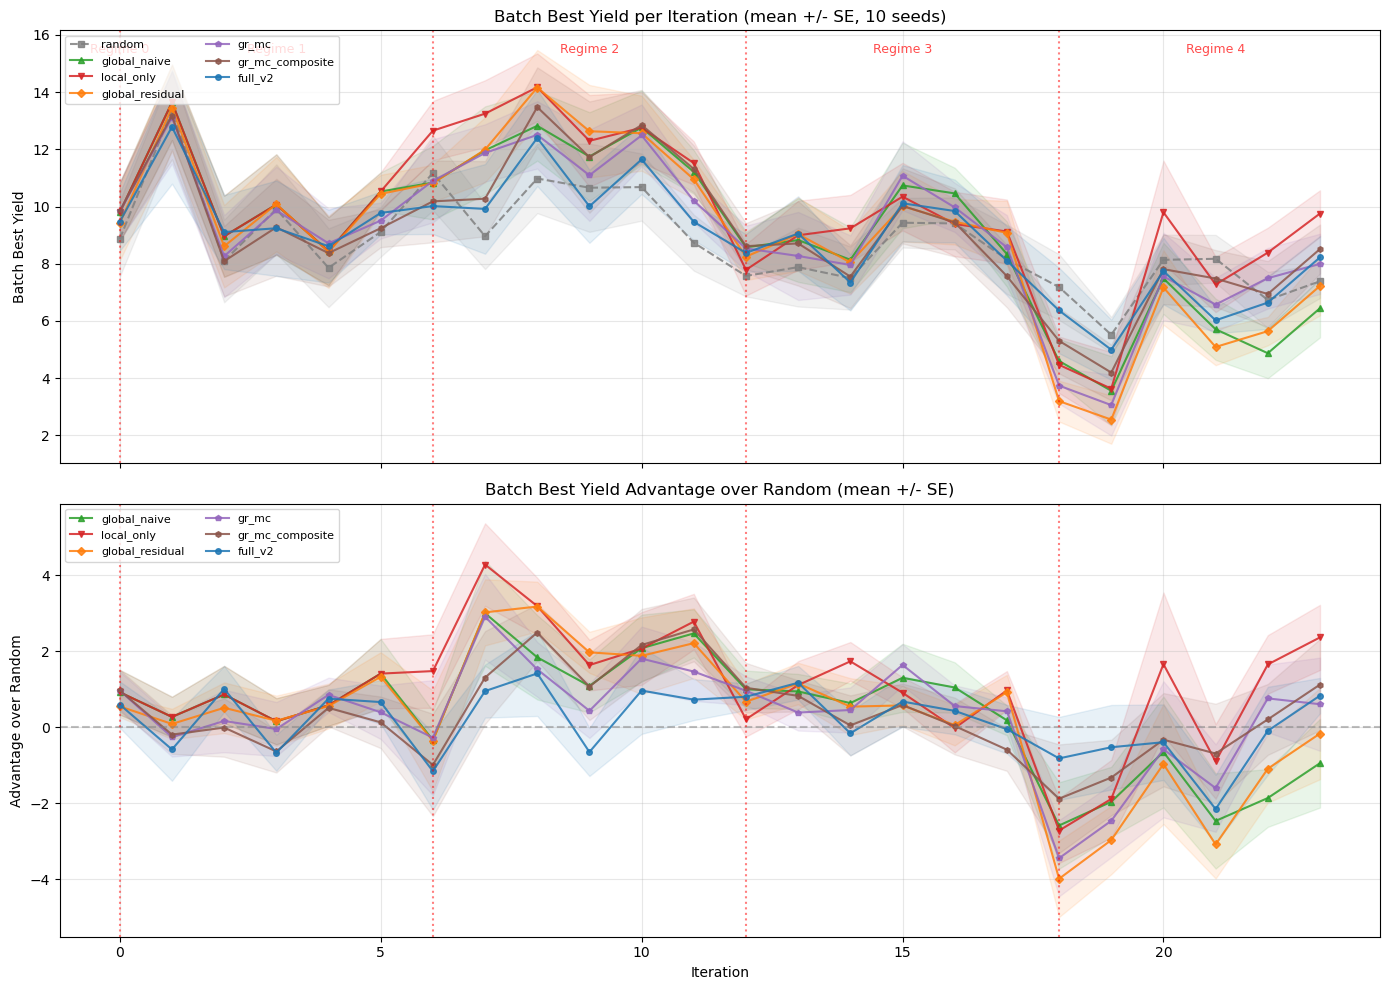

In [14]:
# Collect per-iteration batch_best traces
traces = {}
for method_name in CONFIGS:
    traces[method_name] = np.zeros((N_SEEDS, N_ITERS))
    for s in range(N_SEEDS):
        traces[method_name][s] = results[method_name][42 + s]["batch_best"]

# Advantage over random
random_traces = traces["random"]
iterations = np.arange(N_ITERS)

# Regime transition markers  (uses TRANSITION_ITERS from cell 19)
transition_iters = TRANSITION_ITERS

# Regime labels for annotation
_regime_labels = []
for k in range(len(_regime_iter_boundaries)):
    start = _regime_iter_boundaries[k][0]
    end   = _regime_iter_boundaries[k + 1][0] if k + 1 < len(_regime_iter_boundaries) else N_ITERS
    mid   = (start + end) / 2.0
    _regime_labels.append((mid, _regime_iter_boundaries[k][1]))

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# --- Top panel: raw batch-best traces (mean +/- SE) ---
ax = axes[0]
colors = {"random": "gray", "global_naive": "tab:green", "local_only": "tab:red",
          "global_residual": "tab:orange", "gr_mc": "tab:purple",
          "gr_mc_composite": "tab:brown", "full_v2": "tab:blue"}
styles = {"random": "--", "global_naive": "-", "local_only": "-",
          "global_residual": "-", "gr_mc": "-",
          "gr_mc_composite": "-", "full_v2": "-"}
markers = {"random": "s", "global_naive": "^", "local_only": "v",
           "global_residual": "D", "gr_mc": "p",
           "gr_mc_composite": "h", "full_v2": "o"}

for method_name in CONFIGS:
    mean = traces[method_name].mean(axis=0)
    se = traces[method_name].std(axis=0) / np.sqrt(N_SEEDS)
    ax.plot(iterations, mean, linestyle=styles.get(method_name, "-"),
            marker=markers.get(method_name, "o"),
            color=colors.get(method_name, "tab:blue"),
            label=method_name, linewidth=1.5, markersize=4, alpha=0.85)
    ax.fill_between(iterations, mean - se, mean + se, alpha=0.1,
                    color=colors.get(method_name, "tab:blue"))

for t in transition_iters:
    ax.axvline(t, color="red", linestyle=":", alpha=0.5)
for mid, rid in _regime_labels:
    ax.text(mid, ax.get_ylim()[1]*0.95, f"Regime {rid}", ha="center",
            fontsize=9, color="red", alpha=0.7)
ax.set_ylabel("Batch Best Yield")
ax.set_title("Batch Best Yield per Iteration (mean +/- SE, 10 seeds)")
ax.legend(loc="upper left", fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)

# --- Bottom panel: advantage over random ---
ax = axes[1]
for method_name in CONFIGS:
    if method_name == "random":
        continue
    delta = traces[method_name] - random_traces
    mean_delta = delta.mean(axis=0)
    se_delta = delta.std(axis=0) / np.sqrt(N_SEEDS)
    ax.plot(iterations, mean_delta, linestyle=styles.get(method_name, "-"),
            marker=markers.get(method_name, "o"),
            color=colors.get(method_name, "tab:blue"),
            label=method_name, linewidth=1.5, markersize=4, alpha=0.85)
    ax.fill_between(iterations, mean_delta - se_delta, mean_delta + se_delta,
                    alpha=0.1, color=colors.get(method_name, "tab:blue"))

ax.axhline(0, color="gray", linestyle="--", alpha=0.5)
for t in transition_iters:
    ax.axvline(t, color="red", linestyle=":", alpha=0.5)
ax.set_xlabel("Iteration")
ax.set_ylabel("Advantage over Random")
ax.set_title("Batch Best Yield Advantage over Random (mean +/- SE)")
ax.legend(loc="upper left", fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

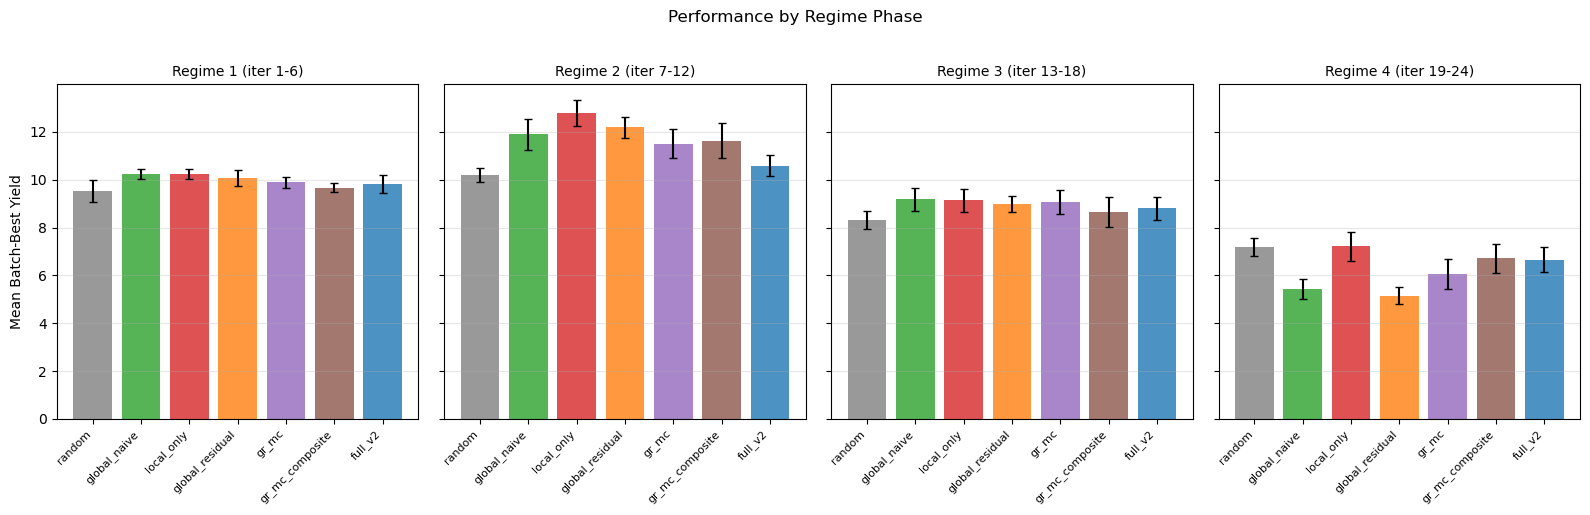

In [15]:
# Grouped bar chart: mean batch best by regime phase
n_phases = len(REGIME_PHASES)
fig, axes = plt.subplots(1, n_phases, figsize=(4 * n_phases, 5), sharey=True)
if n_phases == 1:
    axes = [axes]
method_names = list(CONFIGS.keys())
x = np.arange(len(method_names))

colors = {"random": "gray", "global_naive": "tab:green", "local_only": "tab:red",
          "global_residual": "tab:orange", "gr_mc": "tab:purple",
          "gr_mc_composite": "tab:brown", "full_v2": "tab:blue"}

for ax, (phase_name, iters) in zip(axes, REGIME_PHASES.items()):
    means = []
    errs = []
    for method_name in method_names:
        phase_vals = []
        for s in range(N_SEEDS):
            h = results[method_name][42 + s]
            vals = [h["batch_best"][i] for i in iters if i < len(h["batch_best"])]
            if vals:
                phase_vals.append(np.mean(vals))
        means.append(np.mean(phase_vals))
        errs.append(np.std(phase_vals) / np.sqrt(len(phase_vals)))

    bar_colors = [colors.get(m, "tab:blue") for m in method_names]
    ax.bar(x, means, yerr=errs, color=bar_colors, alpha=0.8, capsize=3)
    ax.set_xticks(x)
    ax.set_xticklabels(method_names, rotation=45, ha="right", fontsize=8)
    ax.set_title(phase_name, fontsize=10)
    ax.grid(True, alpha=0.3, axis="y")

axes[0].set_ylabel("Mean Batch-Best Yield")
plt.suptitle("Performance by Regime Phase", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

### 9e. Statistical Comparisons

Pairwise paired t-tests on mean batch-best yield across 10 seeds.
Focus on the key comparisons that test each hypothesis.


In [16]:
def paired_comparison(method_a, method_b, metric="batch_mean"):
    """Paired t-test between two methods across seeds."""
    vals_a, vals_b = [], []
    for s in range(N_SEEDS):
        ha = results[method_a][42 + s]
        hb = results[method_b][42 + s]
        if metric == "batch_mean":
            vals_a.append(np.mean(ha["batch_best"]))
            vals_b.append(np.mean(hb["batch_best"]))
        elif metric == "cum_best":
            vals_a.append(ha["cumulative_best"][-1])
            vals_b.append(hb["cumulative_best"][-1])
    t_stat, p_val = sp_stats.ttest_rel(vals_a, vals_b)
    diff = np.mean(vals_a) - np.mean(vals_b)
    return {"A": method_a, "B": method_b, "diff": diff,
            "t": t_stat, "p": p_val, "sig": "yes" if p_val < 0.05 else "no"}


comparisons = [
    # Does any adaptive method beat random?
    ("global_naive", "random"),
    ("local_only", "random"),
    ("full_v2", "random"),
    # Does regime awareness help?
    ("local_only", "global_naive"),
    ("global_residual", "global_naive"),
    ("full_v2", "global_naive"),
    # Ablation: value of each improvement
    ("global_residual", "local_only"),      # model structure
    ("gr_mc", "global_residual"),            # MC scoring
    ("gr_mc_composite", "gr_mc"),            # composite acquisition
    ("full_v2", "gr_mc_composite"),          # adaptive batch
]

print("Pairwise Comparisons (Mean Batch-Best Yield):")
print("=" * 85)
comp_rows = [paired_comparison(a, b) for a, b in comparisons]
comp_df = pd.DataFrame(comp_rows)
display(comp_df.round(4))

print("\n\nPairwise Comparisons (Final Cumulative Best):")
print("=" * 85)
comp_rows2 = [paired_comparison(a, b, metric="cum_best") for a, b in comparisons]
comp_df2 = pd.DataFrame(comp_rows2)
display(comp_df2.round(4))


Pairwise Comparisons (Mean Batch-Best Yield):


,A,B,diff,t,p,sig
0,global_naive,random,0.3767,2.4809,0.0349,yes
1,local_only,random,1.0332,4.8985,0.0008,yes
2,full_v2,random,0.1582,0.8590,0.4126,no
3,local_only,global_naive,0.6565,3.4400,0.0074,yes
4,global_residual,global_naive,-0.0922,-0.5254,0.6120,no
5,full_v2,global_naive,-0.2185,-0.9629,0.3608,no
6,global_residual,local_only,-0.7487,-3.2881,0.0094,yes
7,gr_mc,global_residual,0.0359,0.2144,0.8350,no
8,gr_mc_composite,gr_mc,0.0336,0.2642,0.7976,no
9,full_v2,gr_mc_composite,-0.1958,-1.0453,0.3231,no




Pairwise Comparisons (Final Cumulative Best):


,A,B,diff,t,p,sig
0,global_naive,random,0.8523,1.0482,0.3219,no
1,local_only,random,1.4033,2.0043,0.0760,no
2,full_v2,random,0.6751,0.7921,0.4487,no
3,local_only,global_naive,0.5510,1.8958,0.0905,no
4,global_residual,global_naive,0.5636,1.7862,0.1077,no
5,full_v2,global_naive,-0.1771,-0.2514,0.8072,no
6,global_residual,local_only,0.0126,0.0956,0.9259,no
7,gr_mc,global_residual,-0.9871,-1.8542,0.0967,no
8,gr_mc_composite,gr_mc,0.7074,1.2814,0.2321,no
9,full_v2,gr_mc_composite,-0.4611,-0.6014,0.5624,no


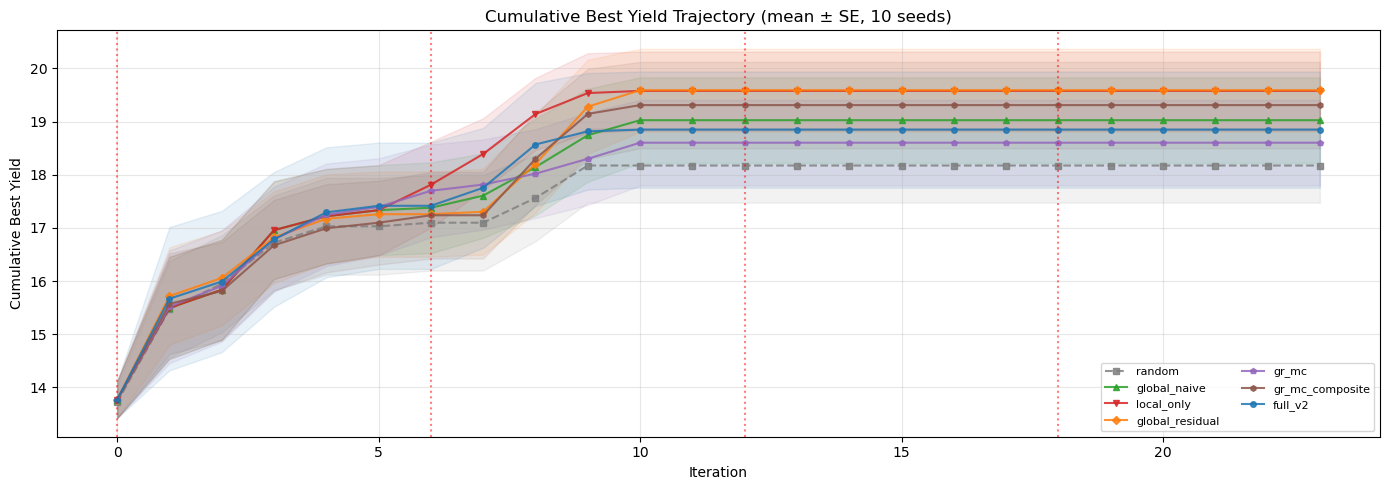

In [17]:
# Cumulative best trajectory over iterations
fig, ax = plt.subplots(figsize=(14, 5))

for method_name in CONFIGS:
    cum_traces = np.zeros((N_SEEDS, N_ITERS))
    for s in range(N_SEEDS):
        cum_traces[s] = results[method_name][42 + s]["cumulative_best"]
    mean_cum = cum_traces.mean(axis=0)
    se_cum = cum_traces.std(axis=0) / np.sqrt(N_SEEDS)
    ax.plot(iterations, mean_cum, linestyle=styles[method_name], marker=markers[method_name],
            color=colors[method_name], label=method_name, linewidth=1.5, markersize=4, alpha=0.85)
    ax.fill_between(iterations, mean_cum - se_cum, mean_cum + se_cum,
                    alpha=0.1, color=colors[method_name])

for t in transition_iters:
    ax.axvline(t, color="red", linestyle=":", alpha=0.5)
ax.set_xlabel("Iteration")
ax.set_ylabel("Cumulative Best Yield")
ax.set_title("Cumulative Best Yield Trajectory (mean ± SE, 10 seeds)")
ax.legend(loc="lower right", fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### 9f. Information Gain Analysis

Information Gain (IG) measures reduction in predictive variance over a fixed
reference set after each batch. It captures **learning** — how much epistemic
uncertainty the surrogate sheds per iteration — independent of whether that
learning translates to higher yield.

- **IG per iteration**: `var_before - var_after` on 200 fixed reference candidates
- **Cumulative IG**: running sum of per-iteration IG
- **IG by regime phase**: do methods learn more in stable or transitional periods?
- **IG–performance correlation**: does faster learning correspond to better yield?

Note: Random baseline has IG = 0 by definition (no surrogate to measure).

In [18]:
# --- IG Summary Table ---
ig_rows = []
for method_name in CONFIGS:
    total_igs = []
    mean_ig_per_iters = []
    for s in range(N_SEEDS):
        h = results[method_name][42 + s]
        total_igs.append(h["cumulative_ig"][-1])
        mean_ig_per_iters.append(np.mean(h["ig"]))

    row = {
        "Method": method_name,
        "Total Cumulative IG (mean)": np.mean(total_igs),
        "Total Cumulative IG (std)": np.std(total_igs),
        "Mean IG per Iter (mean)": np.mean(mean_ig_per_iters),
        "Mean IG per Iter (std)": np.std(mean_ig_per_iters),
    }
    ig_rows.append(row)

ig_summary_df = pd.DataFrame(ig_rows)
print("Information Gain Summary (10 seeds):")
print("=" * 90)
display(ig_summary_df.round(4))

# --- IG by Regime Phase ---
ig_phase_rows = []
for method_name in CONFIGS:
    row = {"Method": method_name}
    for phase_name, iters in REGIME_PHASES.items():
        phase_igs = []
        for s in range(N_SEEDS):
            h = results[method_name][42 + s]
            vals = [h["ig"][i] for i in iters if i < len(h["ig"])]
            if vals:
                phase_igs.append(np.mean(vals))
        row[phase_name] = np.mean(phase_igs) if phase_igs else np.nan
    ig_phase_rows.append(row)

ig_phase_df = pd.DataFrame(ig_phase_rows)
print("\nMean IG per Iteration by Regime Phase:")
print("=" * 90)
display(ig_phase_df.round(4))

# --- Correlation: IG vs Batch-Best Improvement ---
print("\nCorrelation between total cumulative IG and mean batch-best (across seeds):")
print("-" * 70)
# Exclude random (IG is always 0)
for method_name in CONFIGS:
    if method_name == "random":
        continue
    igs = [results[method_name][42 + s]["cumulative_ig"][-1] for s in range(N_SEEDS)]
    bbs = [np.mean(results[method_name][42 + s]["batch_best"]) for s in range(N_SEEDS)]
    if np.std(igs) > 1e-12 and np.std(bbs) > 1e-12:
        r, p = sp_stats.pearsonr(igs, bbs)
        print(f"  {method_name:20s}: r={r:.3f}, p={p:.3f}")
    else:
        print(f"  {method_name:20s}: insufficient variance")


Information Gain Summary (10 seeds):


,Method,Total Cumulative IG (mean),Total Cumulative IG (std),Mean IG per Iter (mean),Mean IG per Iter (std)
0,random,0.0000,0.0000,0.0000,0.0000
1,global_naive,1.0998,0.8854,0.0458,0.0369
2,local_only,1.1774,0.7388,0.0491,0.0308
3,global_residual,1.2977,0.8021,0.0541,0.0334
4,gr_mc,1.1531,0.8238,0.0480,0.0343
5,gr_mc_composite,1.0970,0.6882,0.0457,0.0287
6,full_v2,1.2774,0.7678,0.0532,0.0320



Mean IG per Iteration by Regime Phase:


,Method,Regime 1 (iter 1-6),Regime 2 (iter 7-12),Regime 3 (iter 13-18),Regime 4 (iter 19-24)
0,random,0.0000,0.0000,0.0000,0.0000
1,global_naive,0.0778,0.0970,-0.0040,0.0125
2,local_only,0.0778,0.0879,0.0277,0.0028
3,global_residual,0.0974,0.0592,0.0203,0.0394
4,gr_mc,0.1089,0.0741,-0.0043,0.0135
5,gr_mc_composite,0.0828,0.0903,-0.0075,0.0173
6,full_v2,0.0899,0.0854,-0.0134,0.0510



Correlation between total cumulative IG and mean batch-best (across seeds):
----------------------------------------------------------------------
  global_naive        : r=0.085, p=0.816
  local_only          : r=-0.173, p=0.633
  global_residual     : r=-0.063, p=0.862
  gr_mc               : r=0.058, p=0.874
  gr_mc_composite     : r=0.063, p=0.864
  full_v2             : r=-0.402, p=0.249


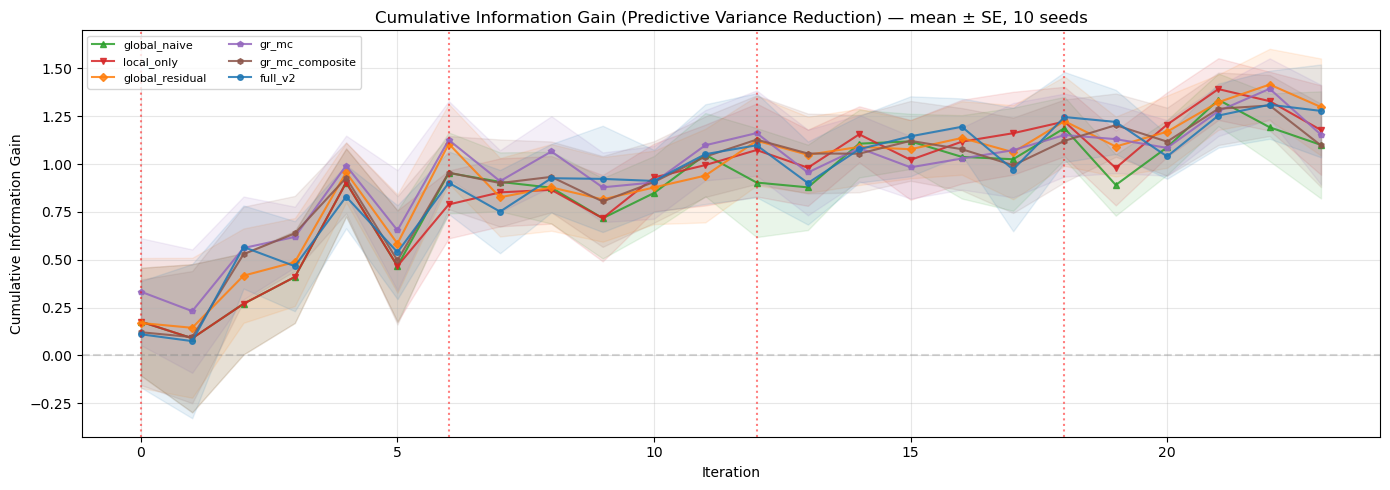

In [19]:
# Cumulative Information Gain over iterations
fig, ax = plt.subplots(figsize=(14, 5))

for method_name in CONFIGS:
    if method_name == "random":
        continue  # IG is 0 for random — skip for clarity
    ig_traces = np.zeros((N_SEEDS, N_ITERS))
    for s in range(N_SEEDS):
        ig_traces[s] = results[method_name][42 + s]["cumulative_ig"]
    mean_ig = ig_traces.mean(axis=0)
    se_ig = ig_traces.std(axis=0) / np.sqrt(N_SEEDS)
    ax.plot(iterations, mean_ig, linestyle=styles[method_name], marker=markers[method_name],
            color=colors[method_name], label=method_name, linewidth=1.5, markersize=4, alpha=0.85)
    ax.fill_between(iterations, mean_ig - se_ig, mean_ig + se_ig,
                    alpha=0.1, color=colors[method_name])

for t in transition_iters:
    ax.axvline(t, color="red", linestyle=":", alpha=0.5)
ax.axhline(0, color="gray", linestyle="--", alpha=0.3)
ax.set_xlabel("Iteration")
ax.set_ylabel("Cumulative Information Gain")
ax.set_title("Cumulative Information Gain (Predictive Variance Reduction) — mean ± SE, 10 seeds")
ax.legend(loc="upper left", fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 10. Summary & Recommendations

This experiment tested 7 configurations in an ablation chain:

1. **random** → floor baseline
2. **global_naive** → value of any adaptive surrogate (no regime awareness)
3. **local_only** → current RA-ADoE (hard regime partition, current approach)
4. **global_residual** → global backbone + regime-specific residual surface
5. **gr_mc** → + Monte Carlo marginalization over nuisance variables
6. **gr_mc_composite** → + composite acquisition (exploit + explore + probe + robust)
7. **full_v2** → + adaptive batch policy (regime-confidence-driven split)

**Key questions answered:**
- Does global+residual outperform local-only? → Tests model structure hypothesis
- Does MC marginalization beat median fill? → Tests nuisance integration hypothesis
- Does composite acquisition beat mean-only? → Tests acquisition function hypothesis
- Does adaptive batching help? → Tests batch policy hypothesis
- Does the full stack (full_v2) significantly beat both the global naive and current local-only?

**Use the per-regime breakdown and recovery metrics** to identify which improvements
matter most *during and after regime transitions* — the scenario where regime awareness
should have the most impact.


---
## 11. Local + Global-Residual Ensemble Evaluation

The corrected results (Section 9) suggest:
- **`local_only`** performs best on mean batch-best and post-transition recovery, exploiting current-regime relevance.
- **`global_residual`** remains competitive on cumulative best and carries cross-regime memory via the global backbone + per-regime residual structure.

These two new ensemble methods test whether **combining local relevance with global-residual memory** improves batch quality, cumulative best, or information gain.

### Ensemble methods

**`local_gr_weighted`** — Weighted combination of local and global-residual predictions.
Ensemble score = 0.65 × z(local) + 0.20 × z(GR) + 0.15 × z(disagreement).
Batch selection: top 4 by ensemble score + 1 random exploration.

**`local_gr_committee`** — Portfolio-based committee selection.
Allocates batch slots by role: 3 local-exploit, 1 consensus (min of z-scored local and GR), 1 disagreement-probe (high local–GR disagreement among above-median local candidates).

### IG approximation note
Information Gain is computed using the **full completed dataset** with expanded features and the standard bootstrap variance estimator (`estimate_predictive_variance`).
This matches the existing global bootstrap style (Option B) and is consistent across all methods.


In [20]:
# ── Ensemble helper functions ──────────────────────────────────────


def zscore_safe(x):
    """Z-score a vector; return zeros if std ≈ 0."""
    x = np.asarray(x, dtype=float)
    s = x.std()
    return (x - x.mean()) / s if s > 1e-12 else np.zeros_like(x)


def build_candidate_feature_frame(candidates, feature_cols, regime_data):
    """Align decision-only candidates to full surrogate feature columns.

    - Decision columns: candidate values
    - Numeric non-decision: current-regime median
    - Categorical non-decision: current-regime mode
    - Fallback: 0.0 (numeric) or "missing" (categorical context)
    """
    aligned = pd.DataFrame(index=candidates.index)
    for col in feature_cols:
        if col in candidates.columns:
            aligned[col] = candidates[col].values
        elif col in regime_data.columns:
            if regime_data[col].dtype.kind in ("f", "i"):
                aligned[col] = float(regime_data[col].median())
            else:
                mode_vals = regime_data[col].mode()
                aligned[col] = mode_vals.iloc[0] if len(mode_vals) > 0 else "missing"
        else:
            if col.startswith("c_context_cat"):
                aligned[col] = "missing"
            else:
                aligned[col] = 0.0
    return aligned


def fit_local_and_gr_bundles(completed, regime_labels, feature_cols, seed):
    """Fit both a local and a global_residual surrogate using existing fit_surrogate."""
    local_bundle = fit_surrogate(
        completed, regime_labels, feature_cols,
        surrogate_type="local", seed=seed)
    gr_bundle = fit_surrogate(
        completed, regime_labels, feature_cols,
        surrogate_type="global_residual", seed=seed + 5000)
    return local_bundle, gr_bundle


def score_local_gr_candidates(candidates, local_bundle, gr_bundle,
                               feature_cols, regime_data):
    """Score candidates with both local and GR models; return all components."""
    aligned = build_candidate_feature_frame(candidates, feature_cols, regime_data)
    local_pred = local_bundle["predict"](aligned)
    gr_pred = gr_bundle["predict"](aligned)

    z_local = zscore_safe(local_pred)
    z_gr = zscore_safe(gr_pred)
    disagreement = np.abs(z_local - z_gr)
    consensus = np.minimum(z_local, z_gr)
    weighted_score = 0.65 * z_local + 0.20 * z_gr + 0.15 * disagreement

    return {
        "local_pred": local_pred, "gr_pred": gr_pred,
        "z_local": z_local, "z_gr": z_gr,
        "disagreement": disagreement, "consensus": consensus,
        "weighted_score": weighted_score,
    }


def select_batch_local_gr_weighted(scores, batch_size=5, seed=42):
    """Weighted policy: top (batch_size - 1) by weighted_score + 1 random."""
    ws = scores["weighted_score"]
    n_exploit = batch_size - 1
    exploit_idx = np.argsort(ws)[::-1][:n_exploit]
    rng = np.random.default_rng(seed)
    remaining = np.setdiff1d(np.arange(len(ws)), exploit_idx)
    explore_idx = rng.choice(remaining, size=min(1, len(remaining)), replace=False)
    return np.concatenate([exploit_idx, explore_idx]).astype(int)


def select_batch_local_gr_committee(scores, batch_size=5, seed=42):
    """Committee policy: 3 local-exploit, 1 consensus, 1 disagreement-probe."""
    z_local = scores["z_local"]
    consensus = scores["consensus"]
    disagreement = scores["disagreement"]
    n_cand = len(z_local)
    rng = np.random.default_rng(seed)

    selected = []
    used = set()

    # 3 local exploit: highest z_local
    local_order = np.argsort(z_local)[::-1]
    for idx in local_order:
        if len(selected) >= 3:
            break
        if idx not in used:
            selected.append(idx)
            used.add(idx)

    # 1 consensus: highest consensus, not already selected
    consensus_order = np.argsort(consensus)[::-1]
    for idx in consensus_order:
        if idx not in used:
            selected.append(idx)
            used.add(idx)
            break

    # 1 disagreement probe: highest disagreement among above-median z_local,
    # excluding already-selected points
    median_z_local = np.median(z_local)
    eligible_mask = (z_local >= median_z_local)
    eligible_idx = np.where(eligible_mask)[0]
    eligible_idx = np.array([i for i in eligible_idx if i not in used])

    if len(eligible_idx) > 0:
        best_disagree = eligible_idx[np.argmax(disagreement[eligible_idx])]
        selected.append(best_disagree)
        used.add(best_disagree)
    else:
        # Fallback: highest disagreement among all remaining
        remaining = np.array([i for i in range(n_cand) if i not in used])
        if len(remaining) > 0:
            best_disagree = remaining[np.argmax(disagreement[remaining])]
            selected.append(best_disagree)
            used.add(best_disagree)

    # Fill any remaining with highest weighted_score
    ws = scores["weighted_score"]
    ws_order = np.argsort(ws)[::-1]
    for idx in ws_order:
        if len(selected) >= batch_size:
            break
        if idx not in used:
            selected.append(idx)
            used.add(idx)

    # Final fallback: random
    while len(selected) < batch_size:
        remaining = [i for i in range(n_cand) if i not in used]
        if remaining:
            idx = rng.choice(remaining)
            selected.append(idx)
            used.add(idx)
        else:
            break

    return np.array(selected[:batch_size], dtype=int)


print("Ensemble helper functions defined:")
print("  zscore_safe, build_candidate_feature_frame, fit_local_and_gr_bundles,")
print("  score_local_gr_candidates, select_batch_local_gr_weighted, select_batch_local_gr_committee")


Ensemble helper functions defined:
  zscore_safe, build_candidate_feature_frame, fit_local_and_gr_bundles,
  score_local_gr_candidates, select_batch_local_gr_weighted, select_batch_local_gr_committee


In [21]:
def run_benchmark_local_gr_ensemble(
    initial_df, oracle, regime_schedule, ensemble_type,
    n_iterations=24, batch_size=5, seed=42,
    X_ref_decisions=None,
):
    """Benchmark loop for local+GR ensemble methods.

    ensemble_type : "weighted" or "committee"

    Tracks the same metrics as run_benchmark: iteration, batch_best,
    cumulative_best, n_runs, true_regime, ig, cumulative_ig.
    """
    df = initial_df.copy()
    run_counter = len(df)
    decision_cols = [c for c in df.columns if c.startswith("d_")]
    bounds = {c: (-1.0, 1.0) for c in decision_cols}
    rng = np.random.default_rng(seed)

    history = {
        "iteration": [], "batch_best": [], "cumulative_best": [],
        "n_runs": [], "true_regime": [],
        "ig": [], "cumulative_ig": [],
    }
    cumulative_ig = 0.0

    # IG: initial variance measurement
    prev_var = None
    if X_ref_decisions is not None:
        completed_init = complete_data(df)
        fc_init = get_feature_cols(completed_init, "expanded")
        X_ref_full = prepare_reference_features(X_ref_decisions, fc_init, completed_init)
        prev_var, _ = estimate_predictive_variance(
            completed_init, fc_init, "t_yield", X_ref_full,
            n_bootstrap=10, seed=seed)

    for it in range(n_iterations):
        # Current true regime from schedule
        current_true_regime = 0
        for threshold, regime in regime_schedule:
            if run_counter >= threshold:
                current_true_regime = regime

        completed = complete_data(df)
        feature_cols = get_feature_cols(completed, "expanded")

        # Regime detection (numeric features only, matching existing logic)
        numeric_feat_cols = [c for c in feature_cols
                            if completed[c].dtype.kind in ("f", "i")]
        regime_labels, _ = detect_regimes(completed, numeric_feat_cols)

        # Fit both surrogates
        local_bundle, gr_bundle = fit_local_and_gr_bundles(
            completed, regime_labels, feature_cols, seed=seed + it)

        # Current regime data
        current_det_regime = regime_labels[-1]
        regime_mask = regime_labels == current_det_regime
        regime_data = completed.loc[regime_mask]

        # Generate candidates
        candidates = generate_candidates(bounds, n_candidates=200, seed=seed + it)

        # Score with both models
        scores = score_local_gr_candidates(
            candidates, local_bundle, gr_bundle, feature_cols, regime_data)

        # Select batch
        if ensemble_type == "weighted":
            selected_idx = select_batch_local_gr_weighted(
                scores, batch_size=batch_size, seed=seed + it)
        elif ensemble_type == "committee":
            selected_idx = select_batch_local_gr_committee(
                scores, batch_size=batch_size, seed=seed + it)
        else:
            raise ValueError(f"Unknown ensemble_type: {ensemble_type}")

        rec_df = candidates.iloc[selected_idx][decision_cols].reset_index(drop=True)

        # Execute via oracle
        new_runs = oracle.evaluate(rec_df, regime=current_true_regime,
                                   run_order_start=run_counter)
        run_counter += len(new_runs)
        df = pd.concat([df, new_runs], ignore_index=True)

        batch_best = float(new_runs["t_yield"].max())
        cum_best = float(df["t_yield"].max())

        # IG: post-iteration variance
        ig_t = 0.0
        if X_ref_decisions is not None:
            completed_post = complete_data(df)
            fc_post = get_feature_cols(completed_post, "expanded")
            X_ref_full_post = prepare_reference_features(
                X_ref_decisions, fc_post, completed_post)
            post_var, _ = estimate_predictive_variance(
                completed_post, fc_post, "t_yield", X_ref_full_post,
                n_bootstrap=10, seed=seed + it + 20000)
            if prev_var is not None:
                ig_t = prev_var - post_var
            prev_var = post_var
        cumulative_ig += ig_t

        history["iteration"].append(it)
        history["batch_best"].append(batch_best)
        history["cumulative_best"].append(cum_best)
        history["n_runs"].append(run_counter)
        history["true_regime"].append(current_true_regime)
        history["ig"].append(ig_t)
        history["cumulative_ig"].append(cumulative_ig)

    return history


print("Ensemble benchmark loop defined (run_benchmark_local_gr_ensemble).")


Ensemble benchmark loop defined (run_benchmark_local_gr_ensemble).


### 11a. Run Ensemble Experiment

Run both ensemble methods across all seeds, using the same oracle, schedule, and reference sets as the existing experiment.


In [22]:
ENSEMBLE_METHODS = {
    "local_gr_weighted": "weighted",
    "local_gr_committee": "committee",
}

ensemble_results = {name: {} for name in ENSEMBLE_METHODS}

t0_ens = time.time()
for s in range(N_SEEDS):
    seed = 42 + s
    print(f"\n--- Seed {seed} ({s+1}/{N_SEEDS}) ---")

    # Same reference set as the main experiment
    X_ref = generate_reference_set(BOUNDS, n_ref=200, seed=seed)

    for method_name, ens_type in ENSEMBLE_METHODS.items():
        oracle = SyntheticOracle(seed=seed)
        history = run_benchmark_local_gr_ensemble(
            initial_df, oracle, SCHEDULE, ensemble_type=ens_type,
            n_iterations=N_ITERS, batch_size=BATCH_SIZE, seed=seed,
            X_ref_decisions=X_ref)
        ensemble_results[method_name][seed] = history

        final = history["cumulative_best"][-1]
        mean_bb = np.mean(history["batch_best"])
        total_ig = history["cumulative_ig"][-1]
        print(f"  {method_name:24s}: cum_best={final:.2f}, mean_batch={mean_bb:.2f}, total_IG={total_ig:.3f}")

elapsed_ens = time.time() - t0_ens
print(f"\nEnsemble experiment time: {elapsed_ens:.1f}s ({elapsed_ens/60:.1f} min)")

# Build combined comparison object
COMPARE_METHODS = [
    "global_naive",
    "local_only",
    "global_residual",
    "local_gr_weighted",
    "local_gr_committee",
]

all_results = {}
for m in COMPARE_METHODS:
    if m in results:
        all_results[m] = results[m]
    elif m in ensemble_results:
        all_results[m] = ensemble_results[m]

print(f"\n[SANITY] Combined comparison methods: {list(all_results.keys())}")
print(f"[SANITY] Seeds per method: { {m: len(v) for m, v in all_results.items()} }")
print(f"[SANITY] Oracle noise override: None (regime-specific noise active)")



--- Seed 42 (1/10) ---
  local_gr_weighted       : cum_best=15.85, mean_batch=10.07, total_IG=0.909
  local_gr_committee      : cum_best=16.26, mean_batch=10.20, total_IG=1.354

--- Seed 43 (2/10) ---
  local_gr_weighted       : cum_best=18.54, mean_batch=8.65, total_IG=1.023
  local_gr_committee      : cum_best=16.28, mean_batch=8.01, total_IG=0.790

--- Seed 44 (3/10) ---
  local_gr_weighted       : cum_best=18.41, mean_batch=9.61, total_IG=0.976
  local_gr_committee      : cum_best=18.43, mean_batch=9.48, total_IG=0.535

--- Seed 45 (4/10) ---
  local_gr_weighted       : cum_best=18.22, mean_batch=9.50, total_IG=0.258
  local_gr_committee      : cum_best=17.03, mean_batch=10.41, total_IG=0.471

--- Seed 46 (5/10) ---
  local_gr_weighted       : cum_best=17.11, mean_batch=9.15, total_IG=2.177
  local_gr_committee      : cum_best=17.47, mean_batch=9.52, total_IG=2.357

--- Seed 47 (6/10) ---
  local_gr_weighted       : cum_best=18.16, mean_batch=9.79, total_IG=1.296
  local_gr_commit

### 11b. Ensemble Comparison — Overall Summary Table


In [23]:
# Overall summary: Cum Best, Batch Best, Total IG
ens_summary_rows = []
for method_name in COMPARE_METHODS:
    cum_bests = [all_results[method_name][42 + s]["cumulative_best"][-1] for s in range(N_SEEDS)]
    batch_means = [np.mean(all_results[method_name][42 + s]["batch_best"]) for s in range(N_SEEDS)]
    total_igs = [all_results[method_name][42 + s]["cumulative_ig"][-1] for s in range(N_SEEDS)]
    ens_summary_rows.append({
        "Method": method_name,
        "Cum Best (mean)": np.mean(cum_bests),
        "Cum Best (std)": np.std(cum_bests),
        "Batch Best (mean)": np.mean(batch_means),
        "Batch Best (std)": np.std(batch_means),
        "Total IG (mean)": np.mean(total_igs),
        "Total IG (std)": np.std(total_igs),
    })

ens_summary_df = pd.DataFrame(ens_summary_rows).set_index("Method")
print("=== Ensemble Comparison — Overall Summary ===")
display(ens_summary_df.round(3))


=== Ensemble Comparison — Overall Summary ===


,Cum Best (mean),Cum Best (std),Batch Best (mean),Batch Best (std),Total IG (mean),Total IG (std)
Method,,,,,,
global_naive,19.026,2.545,9.187,0.891,1.100,0.885
local_only,19.577,2.341,9.844,1.019,1.177,0.739
global_residual,19.589,2.464,9.095,0.533,1.298,0.802
local_gr_weighted,18.681,2.312,9.603,0.733,1.309,0.646
local_gr_committee,18.988,2.418,9.450,0.762,1.233,0.575


### 11c. Per-Regime Performance


In [24]:
# Per-regime mean batch best
ens_regime_rows = []
for method_name in COMPARE_METHODS:
    row = {"Method": method_name}
    for phase_label, phase_iters in REGIME_PHASES.items():
        vals = []
        for s in range(N_SEEDS):
            seed = 42 + s
            bb = all_results[method_name][seed]["batch_best"]
            phase_bb = [bb[i] for i in phase_iters if i < len(bb)]
            if phase_bb:
                vals.append(np.mean(phase_bb))
        row[phase_label] = np.mean(vals) if vals else np.nan
    ens_regime_rows.append(row)

ens_regime_df = pd.DataFrame(ens_regime_rows).set_index("Method")
print("=== Ensemble Comparison — Mean Batch Best by Regime Phase ===")
display(ens_regime_df.round(3))


=== Ensemble Comparison — Mean Batch Best by Regime Phase ===


,Regime 1 (iter 1-6),Regime 2 (iter 7-12),Regime 3 (iter 13-18),Regime 4 (iter 19-24)
Method,,,,
global_naive,10.237,11.890,9.178,5.443
local_only,10.237,12.773,9.146,7.218
global_residual,10.071,12.185,8.980,5.144
local_gr_weighted,9.936,11.890,9.104,7.481
local_gr_committee,10.467,11.532,9.034,6.767


### 11d. Transition Recovery


In [25]:
# Transition recovery: mean batch-best in post-transition windows
ens_recovery_rows = []
for method_name in COMPARE_METHODS:
    row = {"Method": method_name}
    for window_label, window_iters in TRANSITION_WINDOWS.items():
        vals = []
        for s in range(N_SEEDS):
            seed = 42 + s
            bb = all_results[method_name][seed]["batch_best"]
            window_bb = [bb[i] for i in window_iters if i < len(bb)]
            if window_bb:
                vals.append(np.mean(window_bb))
        row[window_label] = np.mean(vals) if vals else np.nan
    ens_recovery_rows.append(row)

ens_recovery_df = pd.DataFrame(ens_recovery_rows).set_index("Method")
print("=== Ensemble Comparison — Transition Recovery ===")
display(ens_recovery_df.round(3))


=== Ensemble Comparison — Transition Recovery ===


,After transition 1 (iter 1-5),After transition 2 (iter 7-11),After transition 3 (iter 13-17),After transition 4 (iter 19-23)
Method,,,,
global_naive,10.180,12.026,9.346,5.243
local_only,10.180,13.024,9.150,6.711
global_residual,9.997,12.432,8.961,4.728
local_gr_weighted,9.899,12.073,9.182,7.018
local_gr_committee,10.463,11.661,9.210,6.112


### 11e. Improvement Rate Over Random


In [26]:
# Improvement rate: fraction of iterations where method beats random-phase mean
# Use random baseline from existing results
random_batch_by_iter = np.zeros(N_ITERS)
for s in range(N_SEEDS):
    seed = 42 + s
    random_batch_by_iter += np.array(results["random"][seed]["batch_best"])
random_batch_by_iter /= N_SEEDS  # per-iteration random mean

ens_improv_rows = []
for method_name in COMPARE_METHODS:
    fracs = []
    for s in range(N_SEEDS):
        seed = 42 + s
        bb = np.array(all_results[method_name][seed]["batch_best"])
        frac = np.mean(bb > random_batch_by_iter[:len(bb)])
        fracs.append(frac)
    ens_improv_rows.append({
        "Method": method_name,
        "Frac beating random (mean)": np.mean(fracs),
        "Frac beating random (std)": np.std(fracs),
    })

ens_improv_df = pd.DataFrame(ens_improv_rows).set_index("Method")
print("=== Ensemble Comparison — Improvement Rate Over Random ===")
display(ens_improv_df.round(3))


=== Ensemble Comparison — Improvement Rate Over Random ===


,Frac beating random (mean),Frac beating random (std)
Method,,
global_naive,0.542,0.087
local_only,0.588,0.117
global_residual,0.512,0.093
local_gr_weighted,0.567,0.046
local_gr_committee,0.546,0.088


### 11f. Pairwise Statistical Comparisons

Paired t-tests on mean batch-best and final cumulative-best across 10 seeds.


In [27]:
from scipy import stats as sp_stats

PAIRWISE_COMPARISONS = [
    ("local_gr_weighted", "local_only"),
    ("local_gr_weighted", "global_residual"),
    ("local_gr_weighted", "global_naive"),
    ("local_gr_committee", "local_only"),
    ("local_gr_committee", "global_residual"),
    ("local_gr_committee", "global_naive"),
    ("local_gr_committee", "local_gr_weighted"),
]

pw_rows = []
for method_a, method_b in PAIRWISE_COMPARISONS:
    # Mean batch-best per seed
    a_batch = [np.mean(all_results[method_a][42 + s]["batch_best"]) for s in range(N_SEEDS)]
    b_batch = [np.mean(all_results[method_b][42 + s]["batch_best"]) for s in range(N_SEEDS)]
    t_bb, p_bb = sp_stats.ttest_rel(a_batch, b_batch)
    diff_bb = np.mean(a_batch) - np.mean(b_batch)

    # Final cumulative best per seed
    a_cum = [all_results[method_a][42 + s]["cumulative_best"][-1] for s in range(N_SEEDS)]
    b_cum = [all_results[method_b][42 + s]["cumulative_best"][-1] for s in range(N_SEEDS)]
    t_cum, p_cum = sp_stats.ttest_rel(a_cum, b_cum)
    diff_cum = np.mean(a_cum) - np.mean(b_cum)

    sig_bb = "***" if p_bb < 0.001 else ("**" if p_bb < 0.01 else ("*" if p_bb < 0.05 else ""))
    sig_cum = "***" if p_cum < 0.001 else ("**" if p_cum < 0.01 else ("*" if p_cum < 0.05 else ""))

    pw_rows.append({
        "Comparison": f"{method_a} vs {method_b}",
        "Batch Δ": diff_bb,
        "Batch p": p_bb,
        "Batch sig": sig_bb,
        "Cum Δ": diff_cum,
        "Cum p": p_cum,
        "Cum sig": sig_cum,
    })

pw_df = pd.DataFrame(pw_rows)
print("=== Pairwise Statistical Comparisons (paired t-test, 10 seeds) ===")
display(pw_df.round(4))


=== Pairwise Statistical Comparisons (paired t-test, 10 seeds) ===


,Comparison,Batch Δ,Batch p,Batch sig,Cum Δ,Cum p,Cum sig
0,local_gr_weighted vs local_only,-0.2410,0.2380,,-0.8952,0.1852,
1,local_gr_weighted vs global_residual,0.5077,0.0014,**,-0.9079,0.1970,
2,local_gr_weighted vs global_naive,0.4155,0.0248,*,-0.3443,0.6220,
3,local_gr_committee vs local_only,-0.3938,0.2487,,-0.5880,0.3146,
4,local_gr_committee vs global_residual,0.3549,0.1279,,-0.6007,0.3673,
5,local_gr_committee vs global_naive,0.2627,0.3502,,-0.0371,0.9463,
6,local_gr_committee vs local_gr_weighted,-0.1527,0.5850,,0.3072,0.6474,


### 11g. Visualizations


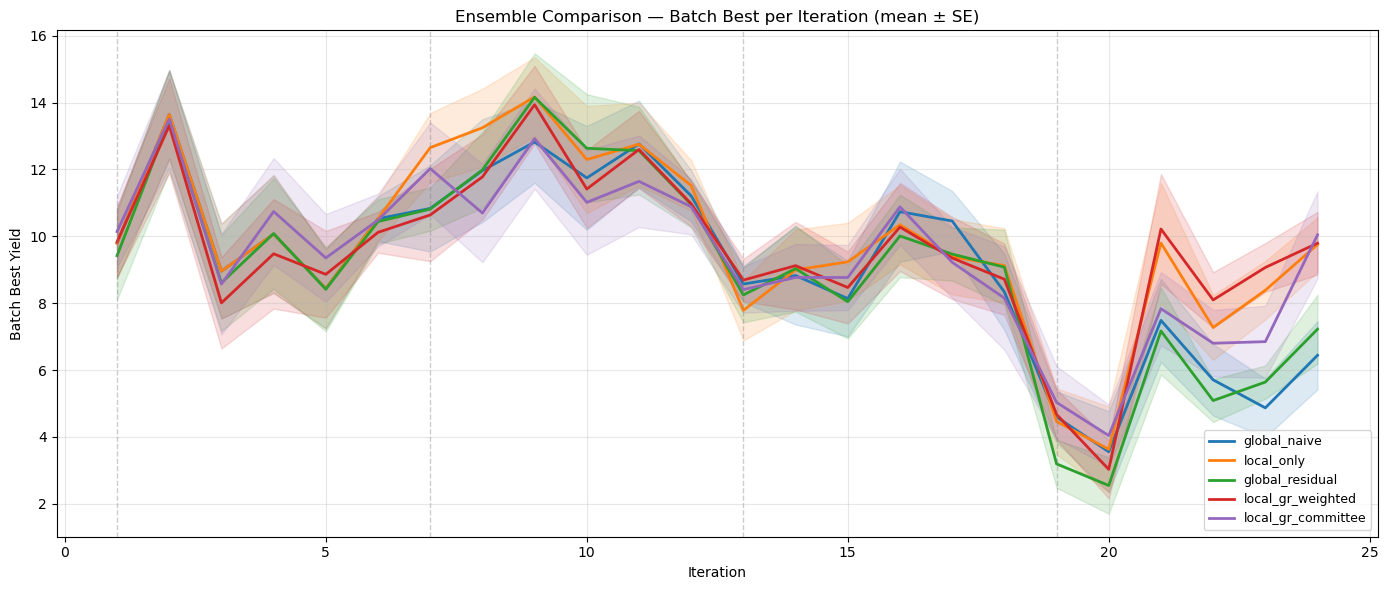

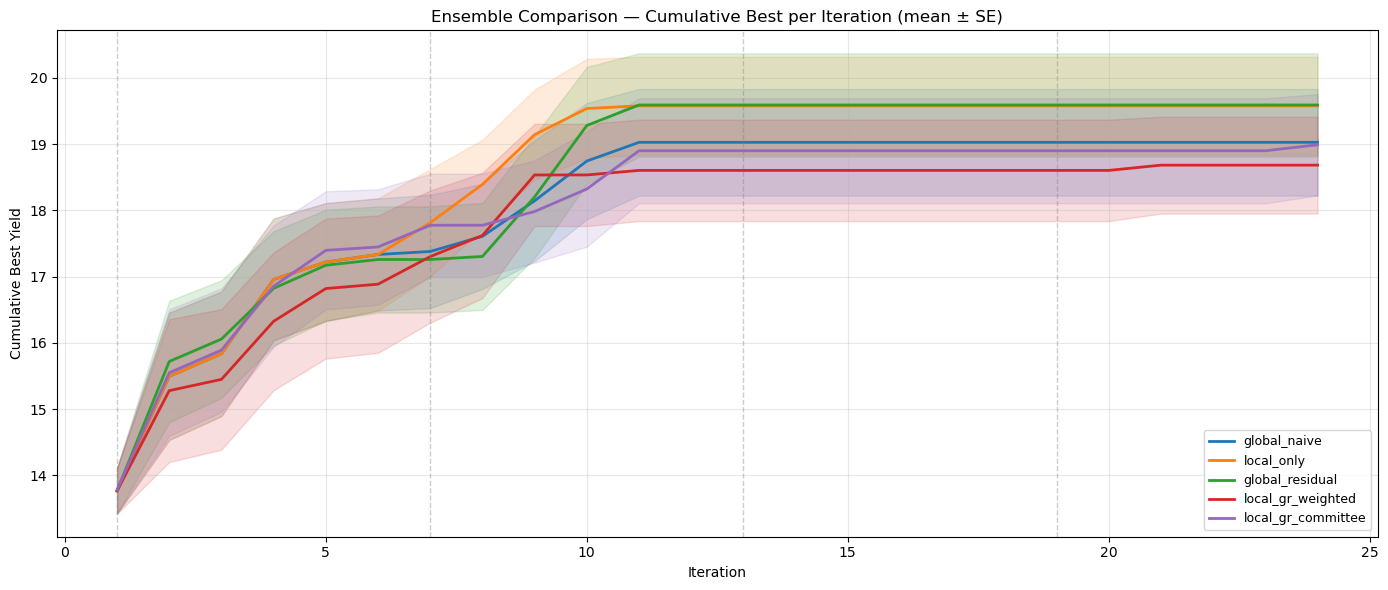

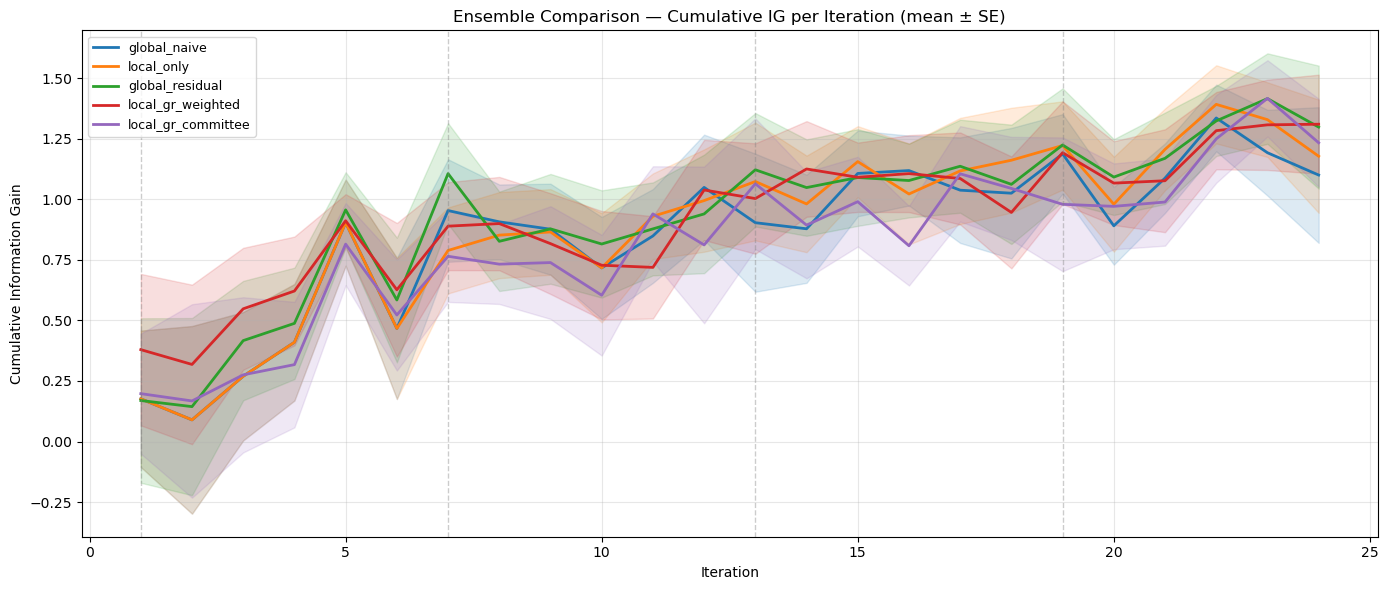

In [28]:
# Collect per-iteration traces for COMPARE_METHODS
ens_traces_bb = {}
ens_traces_cum = {}
ens_traces_ig = {}
for method_name in COMPARE_METHODS:
    bb_arr = np.zeros((N_SEEDS, N_ITERS))
    cum_arr = np.zeros((N_SEEDS, N_ITERS))
    ig_arr = np.zeros((N_SEEDS, N_ITERS))
    for s in range(N_SEEDS):
        seed = 42 + s
        h = all_results[method_name][seed]
        bb_arr[s] = h["batch_best"]
        cum_arr[s] = h["cumulative_best"]
        ig_arr[s] = h["cumulative_ig"]
    ens_traces_bb[method_name] = bb_arr
    ens_traces_cum[method_name] = cum_arr
    ens_traces_ig[method_name] = ig_arr

iterations = np.arange(1, N_ITERS + 1)

# Color palette
_colors = {
    "global_naive":       "tab:blue",
    "local_only":         "tab:orange",
    "global_residual":    "tab:green",
    "local_gr_weighted":  "tab:red",
    "local_gr_committee": "tab:purple",
}

# ── Plot 1: Batch-best per iteration ──
fig, ax = plt.subplots(figsize=(14, 6))
for method_name in COMPARE_METHODS:
    arr = ens_traces_bb[method_name]
    mean = arr.mean(axis=0)
    se = arr.std(axis=0) / np.sqrt(N_SEEDS)
    ax.plot(iterations, mean, label=method_name, color=_colors[method_name], linewidth=2)
    ax.fill_between(iterations, mean - se, mean + se, alpha=0.15, color=_colors[method_name])

for t_iter in TRANSITION_ITERS:
    ax.axvline(x=t_iter + 1, color="gray", linestyle="--", alpha=0.4, linewidth=1)

ax.set_xlabel("Iteration")
ax.set_ylabel("Batch Best Yield")
ax.set_title("Ensemble Comparison — Batch Best per Iteration (mean ± SE)")
ax.legend(loc="lower right", fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ── Plot 2: Cumulative best per iteration ──
fig, ax = plt.subplots(figsize=(14, 6))
for method_name in COMPARE_METHODS:
    arr = ens_traces_cum[method_name]
    mean = arr.mean(axis=0)
    se = arr.std(axis=0) / np.sqrt(N_SEEDS)
    ax.plot(iterations, mean, label=method_name, color=_colors[method_name], linewidth=2)
    ax.fill_between(iterations, mean - se, mean + se, alpha=0.15, color=_colors[method_name])

for t_iter in TRANSITION_ITERS:
    ax.axvline(x=t_iter + 1, color="gray", linestyle="--", alpha=0.4, linewidth=1)

ax.set_xlabel("Iteration")
ax.set_ylabel("Cumulative Best Yield")
ax.set_title("Ensemble Comparison — Cumulative Best per Iteration (mean ± SE)")
ax.legend(loc="lower right", fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ── Plot 3: Cumulative IG per iteration ──
fig, ax = plt.subplots(figsize=(14, 6))
for method_name in COMPARE_METHODS:
    arr = ens_traces_ig[method_name]
    mean = arr.mean(axis=0)
    se = arr.std(axis=0) / np.sqrt(N_SEEDS)
    ax.plot(iterations, mean, label=method_name, color=_colors[method_name], linewidth=2)
    ax.fill_between(iterations, mean - se, mean + se, alpha=0.15, color=_colors[method_name])

for t_iter in TRANSITION_ITERS:
    ax.axvline(x=t_iter + 1, color="gray", linestyle="--", alpha=0.4, linewidth=1)

ax.set_xlabel("Iteration")
ax.set_ylabel("Cumulative Information Gain")
ax.set_title("Ensemble Comparison — Cumulative IG per Iteration (mean ± SE)")
ax.legend(loc="upper left", fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### 11h. Interpretation

*Interpretation notes (to be completed after reviewing the numbers above):*

- Does either ensemble improve mean batch-best over `local_only`?
- Does either ensemble improve cumulative best over `local_only` or `global_residual`?
- Does the committee method improve late-regime or post-transition performance?
- Does ensemble disagreement appear to improve information gain?
- If ensemble methods do not improve results, `local_only` may already be the best current exploitation policy under hard drift.
